SAMIR BELASRI OC Checklist Projet – Analyse de données de systèmes éducatifs (Google Colab, Python, Pandas, Seaborn, Matplotlib, Numpy)

Phase 0 – Préparation environnement
•	Vérifier que Google Colab fonctionne correctement.
•	Créer un Notebook dédié au projet.
•	Importer les librairies nécessaires : pandas, numpy, matplotlib.pyplot, seaborn.
•	Monter Google Drive si les fichiers sont stockés dessus.
•	Charger les 5 fichiers de données dans des DataFrames Pandas.

Exercice partie 1 - Analysez des données de systèmes éducatifs
Phase 1 – Exploration initiale (Partie 1, Étape 1 et 2)
•	Afficher les 5 premières lignes de chaque fichier (.head()).
•	Définir ce que représente une ligne dans chaque dataset (pays, indicateur, etc.).
•	Calculer taille des datasets (.shape).
•	Détecter et supprimer les doublons (.duplicated(), .drop_duplicates()).
•	Quantifier les valeurs manquantes par colonne (.isnull().mean()).
•	Supprimer colonnes inutilisables (ex. trop de valeurs manquantes).
•	Décrire les colonnes numériques (.describe()).
•	Décrire les colonnes catégorielles (.value_counts()).
•	Ajouter du markdown explicatif dans le Notebook.

Phase 2 – Nettoyage des faux pays (Partie 1, Étape 3)
•	Identifier les faux pays dans le fichier Country.
•	Supprimer ces lignes du dataframe Country.
•	Créer une liste des faux pays pour filtrer les autres fichiers.
•	Appliquer un inner join entre Country nettoyé et les autres datasets.
•	Vérifier la cohérence des années et définir la stratégie (quelles années garder).

Phase 3 – Auto-évaluation intermédiaire (Partie 1, Étape 4)
•	Vérifier la cohérence entre les valeurs manquantes et le besoin métier.
•	Vérifier suppression correcte des doublons et faux pays.
•	Construire une matrice de corrélation (.corr(), Seaborn heatmap).
•	Documenter les choix métiers (indicateurs conservés, années filtrées).
•	Insérer du markdown clair et structuré.

Exercice partie 2 - Analysez des données de systèmes éducatifs

Phase 4 – Sélection d’indicateurs (Partie 2, Étape 1 et 2)
•	Identifier la colonne catégorielle des indicateurs.
•	Sélectionner les catégories pertinentes selon la demande métier.
•	Filtrer les datasets pour ne garder que ces indicateurs.
•	Interpréter les colonnes représentant les années.
•	Filtrer les années non pertinentes (futures ou trop incomplètes).
•	Calculer proportion de données disponibles :
o	par année,
o	par indicateur.
•	Sélectionner ~15 indicateurs riches en données.
•	Documenter le raisonnement métier et statistique.

Phase 5 – Transformation et agrégation (Partie 2, Étape 3)
•	Filtrer Data pour ne garder que pays, années et indicateurs retenus.
•	Transformer avec pivot_table() pour obtenir :
o	lignes = pays,
o	colonnes = indicateurs,
o	valeurs = agrégation (moyenne, médiane, etc.).
•	Vérifier la qualité des données par pays et indicateur.
•	Ajouter du markdown décrivant l’approche.

Exercice partie 3 - Analysez des données de systèmes éducatifs
Phase 6 – Réduction de la redondance (Partie 3, Étape 1)
•	Calculer matrice de corrélation (Pearson et Spearman).
•	Visualiser avec heatmap Seaborn.
•	Identifier indicateurs trop corrélés (>70%).
•	Supprimer les indicateurs redondants.
•	Garder les plus pertinents métier.

Phase 7 – Analyse approfondie et sélection des pays (Partie 3, Étape 2)
•	Choisir un indicateur et analyser sa distribution (describe(), displot()).
•	Créer une fonction pour répéter l’analyse sur tous les indicateurs.
•	Interpréter la distribution de chaque indicateur.
•	Définir une méthode quantitative de sélection de pays (ex. top 5 par indicateur, moyenne pondérée).
•	Construire la liste finale des pays pertinents pour l’expansion.

Phase 8 – Restitution et storytelling (Partie 3, Étape 3 et 4)
•	Créer une présentation PowerPoint avec Canva.
•	Introduire le contexte métier et la problématique initiale.
•	Présenter :
o	contenu des datasets,
o	étapes de nettoyage et transformation,
o	analyses descriptives et corrélations,
o	indicateurs et pays retenus.
•	Ajouter visualisations lisibles (axes, titres, légendes).
•	Structurer avec un storytelling orienté décision.
•	Vérifier que les hypothèses sont documentées et justifiées.

Points importants :
-Pandas
- Numpy
- Seaborn
- Matplotlib
- Logique métier (pertinence des indicateurs, sélection des pays).
- Markdowns


# Mon Dossier d'Analyse des Systèmes Éducatifs

Bienvenue dans ce notebook qui retrace toutes les étapes de mon analyse des données sur les systèmes éducatifs, réalisée dans le but d'aider à identifier des pays potentiels pour une expansion. J'ai suivi un processus structuré, du chargement initial des données à la sélection des pays cibles, en passant par le nettoyage, l'exploration des indicateurs, la réduction de la redondance et l'analyse approfondie.

Dans ce dossier, je vous présente ma démarche complète, mes observations clés, et mes conclusions.

## Exercice 1 - Découverte et Nettoyage des Données

Mon premier objectif dans cette étude était de prendre connaissance des données disponibles, de les charger correctement et de les nettoyer pour qu'elles soient prêtes à être analysées en toute confiance.

### Phase 1 – Découverte initiale des fichiers et chargement des données

Pour commencer mon analyse, j'ai eu accès à plusieurs fichiers de données. Ma première tâche a été de charger ces fichiers dans mon environnement de travail, en utilisant la librairie pandas en Python, afin de pouvoir les explorer et les manipuler.

**Mon objectif :** Charger les cinq fichiers CSV fournis dans des DataFrames pandas.

**Les fichiers que j'ai chargés se trouvent dans le dossier :** `/content/drive/MyDrive/Colab Notebooks/Projet_1_DATA_ENGINEER/data_folder`.

Les fichiers sont :
*   `EdStatsCountry.csv` : Contient des informations descriptives sur les pays.
*   `EdStatsSeries.csv` : Décrit les différents indicateurs présents dans le dataset.
*   `EdStatsData.csv` : Le fichier principal contenant les valeurs des indicateurs pour différents pays et années.
*   `EdStatsCountry-Series.csv` : Fournit des liens entre les pays et les séries d'indicateurs disponibles.
*   `EdStatsFootNote.csv` : Comporte des notes de bas de page ou des informations additionnelles pour certaines données.

In [147]:
import pandas as pd
import os

# Je définis le chemin d'accès à mon dossier de données
data_folder_path = '/content/drive/MyDrive/Colab Notebooks/Projet_1_DATA_ENGINEER/data_folder'

# Je m'assure que le chemin existe
if not os.path.exists(data_folder_path):
    print(f"Erreur : Le dossier de données '{data_folder_path}' n'a pas été trouvé.")
    print("Veuillez vérifier que Google Drive est bien monté et que le chemin d'accès est correct.")
else:
    # Je charge les différents fichiers CSV dans des DataFrames
    try:
        edstats_country_df = pd.read_csv(os.path.join(data_folder_path, 'EdStatsCountry.csv'))
        edstats_series_df = pd.read_csv(os.path.join(data_folder_path, 'EdStatsSeries.csv'))
        edstats_data_df = pd.read_csv(os.path.join(data_folder_path, 'EdStatsData.csv'))
        edstats_country_series_df = pd.read_csv(os.path.join(data_folder_path, 'EdStatsCountry-Series.csv'))
        edstats_footnote_df = pd.read_csv(os.path.join(data_folder_path, 'EdStatsFootNote.csv'))

        # Je stocke mes DataFrames dans un dictionnaire pour les retrouver facilement tout au long de mon analyse
        dataframes = {
            'EdStatsCountry': edstats_country_df,
            'EdStatsSeries': edstats_series_df,
            'EdStatsData': edstats_data_df,
            'EdStatsCountry-Series': edstats_country_series_df,
            'EdStatsFootNote': edstats_footnote_df
        }

        print("Tous les fichiers ont été chargés avec succès dans des DataFrames.")

    except FileNotFoundError as e:
        print(f"Erreur : Le fichier {e.filename} n'a pas été trouvé dans le dossier spécifié.")
    except Exception as e:
        print(f"Une erreur s'est produite lors du chargement des fichiers : {e}")

Tous les fichiers ont été chargés avec succès dans des DataFrames.


## Exercice 2 - Analyse des données de systèmes éducatifs

Maintenant que mes données sont nettoyées et que je ne travaille qu'avec les pays réels, je vais pouvoir me concentrer sur les indicateurs qui m'intéressent le plus et préparer mon tableau principal pour l'analyse.

### Phase 4 – Sélection d’indicateurs

Cette phase est essentielle pour affiner mon analyse. Après avoir nettoyé les données et identifié les années les plus pertinentes (nous avons vu qu'il y avait plus de données pour les années récentes comme 2005 et 2010), je vais maintenant me concentrer sur la sélection des indicateurs les plus utiles et les plus complets pour répondre à mes objectifs.

**Ce que je vais faire dans cette phase :**
*   **Trouver les indicateurs :** Regarder où se trouvent les descriptions des indicateurs dans mes fichiers.
*   **Choisir mes indicateurs :** Sélectionner les indicateurs qui sont importants pour mon analyse, en fonction de ce que je veux comprendre.
*   **Garder seulement les indicateurs choisis :** Filtrer mes données pour ne garder que les informations liées à mes indicateurs sélectionnés.
*   **Regarder les années :** Confirmer quelles années je vais utiliser (nous avons déjà vu que 2005 et 2010 sont les plus complètes).
*   **Vérifier la quantité de données :** Compter combien de données sont disponibles pour chaque indicateur et pour chaque année choisie.
*   **Garder les meilleurs indicateurs :** Sélectionner environ 15 indicateurs qui ont beaucoup de données pour les années 2005 et 2010.
*   **Tout expliquer :** Noter pourquoi j'ai choisi ces indicateurs et ces années.

#### Documentation du nettoyage des données

Dans cette Phase 2, j'ai réalisé plusieurs étapes importantes pour nettoyer les données et les préparer pour l'analyse.

**Récapitulatif des étapes de nettoyage :**

1.  **Identification et suppression des colonnes très vides :** J'ai calculé le pourcentage de valeurs manquantes par colonne dans le DataFrame `EdStatsData` et j'ai supprimé les colonnes qui contenaient plus de 90% de valeurs manquantes, car elles n'étaient pas utiles pour l'analyse.
2.  **Identification des pays réels :** J'ai utilisé le DataFrame `EdStatsCountry` pour identifier les pays qui ne sont pas des agrégats (regroupements). Je me suis basé sur la présence d'informations sur la région et le groupe de revenu pour distinguer les pays réels.
3.  **Filtrage des DataFrames par pays réels :** J'ai utilisé la liste des codes pays réels pour filtrer les DataFrames `EdStatsData`, `EdStatsCountry-Series` et `EdStatsFootNote` afin de ne conserver que les données liées aux pays individuels. Le DataFrame `EdStatsCountry` a également été nettoyé pour ne garder que les entrées correspondant aux pays réels.

Ces étapes ont permis de réduire la taille des DataFrames et de s'assurer que l'analyse portera sur des entités géographiques pertinentes (les pays).

---
### Conclusion Intermédiaire - Exercice 1 : Découverte et Nettoyage

L'Exercice 1, axé sur la découverte et le nettoyage initial de mes données, est maintenant terminé. J'ai pu réaliser les objectifs suivants :

1.  **Chargement et exploration initiale :** J'ai chargé tous les fichiers CSV dans des DataFrames et j'ai eu un premier aperçu de leur contenu, de leur structure et des colonnes disponibles. J'ai identifié les DataFrames clés pour l'analyse (`EdStatsCountry`, `EdStatsSeries`, `EdStatsData`) et compris leurs relations.
2.  **Gestion des valeurs manquantes :** J'ai identifié et supprimé les colonnes du DataFrame `EdStatsData` qui contenaient une proportion excessive de valeurs manquantes, simplifiant ainsi le tableau.
3.  **Filtrage des agrégats :** J'ai réussi à identifier et à retirer les regroupements géographiques ou économiques des DataFrames, me permettant de travailler uniquement avec les données de pays réels pour la suite de mon analyse.

Malgré ces étapes de nettoyage, je sais qu'il reste encore des valeurs manquantes dans les DataFrames, notamment dans les colonnes d'années du tableau `EdStatsData_cleaned_by_list`. La prochaine étape consistera à sélectionner les indicateurs et les années les plus pertinents, tout en tenant compte de cette incomplétude des données.

Je suis maintenant prêt(e) à passer à l'**Exercice 2 : Analyse des données de systèmes éducatifs**, qui débutera par la **Phase 4 : Sélection d’indicateurs**.

#### Identification et filtrage des "faux pays" (agrégats)

Le dataset contient des entrées qui ne sont pas des pays individuels, mais des regroupements géographiques ou économiques (comme des continents, des groupes de revenu, etc.). Pour mon analyse qui vise à identifier des pays spécifiques pour l'expansion, je dois filtrer ces "agrégats" et ne conserver que les pays réels.

**Mon objectif :** Utiliser le DataFrame `EdStatsCountry` pour identifier les pays réels et filtrer les DataFrames `EdStatsData`, `EdStatsCountry-Series` et `EdStatsFootNote` pour ne garder que les données liées à ces pays.

**Explication :**

Le DataFrame `EdStatsCountry` contient des informations qui me permettent de distinguer les pays réels des agrégats. Souvent, les pays réels ont des informations complètes sur leur région et leur groupe de revenu, contrairement aux agrégats. Je vais utiliser ce critère pour identifier les codes pays réels.

Ensuite, j'utiliserai cette liste de codes pays réels pour filtrer les DataFrames `EdStatsData` (qui contient mes données d'indicateurs), `EdStatsCountry-Series` et `EdStatsFootNote`.

In [153]:
# Je m'assure que les DataFrames nécessaires sont disponibles dans le dictionnaire
if 'EdStatsCountry' in dataframes and 'EdStatsData' in dataframes:
    edstats_country_df = dataframes['EdStatsCountry']
    edstats_data_df = dataframes['EdStatsData']

    # J'identifie les pays réels en me basant sur la présence d'une Région et d'un Groupe de Revenu non nul.
    # C'est une heuristique qui fonctionne souvent pour ce type de données.
    real_countries_df = edstats_country_df[
        edstats_country_df['Region'].notnull() & edstats_country_df['Income Group'].notnull()
    ].copy() # J'utilise .copy() pour éviter SettingWithCopyWarning

    # Je récupère la liste des codes pays réels
    real_country_codes = real_countries_df['Country Code'].tolist()

    print(f"\nNombre total d'entrées dans EdStatsCountry : {edstats_country_df.shape[0]}")
    print(f"Nombre de pays réels identifiés : {len(real_country_codes)}")

    # Je filtre le DataFrame principal des données d'indicateurs pour ne garder que les pays réels
    edstats_data_cleaned = edstats_data_df[edstats_data_df['Country Code'].isin(real_country_codes)].copy()
    dataframes['EdStatsData_cleaned_by_list'] = edstats_data_cleaned # Je mets à jour le dictionnaire

    print(f"\nNombre de lignes dans EdStatsData après filtrage des agrégats : {edstats_data_cleaned.shape[0]}")


    # Je filtre aussi les autres DataFrames si elles existent dans le dictionnaire et si elles ont la colonne 'Country Code'
    dataframes_to_check_filtering = {
        'EdStatsCountry-Series': 'EdStatsCountry-Series_cleaned_by_list',
        'EdStatsFootNote': 'EdStatsFootNote_cleaned_by_list'
    }

    for df_name, cleaned_df_name in dataframes_to_check_filtering.items():
        if df_name in dataframes and 'Country Code' in dataframes[df_name].columns:
            original_df = dataframes[df_name]
            cleaned_df = original_df[original_df['Country Code'].isin(real_country_codes)].copy()
            dataframes[cleaned_df_name] = cleaned_df
            print(f"Nombre de lignes dans {df_name} après filtrage des agrégats : {cleaned_df.shape[0]}")
        else:
            print(f"Le DataFrame '{df_name}' n'a pas été trouvé ou ne contient pas la colonne 'Country Code'. Il n'a pas été filtré par liste de pays.")


    # Je garde aussi le DataFrame des pays réels nettoyé
    dataframes['EdStatsCountry_cleaned'] = real_countries_df.copy()
    print(f"Nombre de lignes dans EdStatsCountry après filtrage des agrégats : {dataframes['EdStatsCountry_cleaned'].shape[0]}")


else:
    print("Les DataFrames 'EdStatsCountry' ou 'EdStatsData' nécessaires n'ont pas été trouvés dans le dictionnaire.")


Nombre total d'entrées dans EdStatsCountry : 241
Nombre de pays réels identifiés : 214

Nombre de lignes dans EdStatsData après filtrage des agrégats : 784310
Le DataFrame 'EdStatsCountry-Series' n'a pas été trouvé ou ne contient pas la colonne 'Country Code'. Il n'a pas été filtré par liste de pays.
Le DataFrame 'EdStatsFootNote' n'a pas été trouvé ou ne contient pas la colonne 'Country Code'. Il n'a pas été filtré par liste de pays.
Nombre de lignes dans EdStatsCountry après filtrage des agrégats : 214


#### Suppression des colonnes très vides

Après avoir identifié les colonnes avec un pourcentage très élevé de valeurs manquantes, je vais les supprimer de mon DataFrame principal. Cela me permettra de travailler avec un tableau plus léger et potentiellement plus pertinent.

**Mon objectif :** Supprimer les colonnes identifiées comme très vides dans le DataFrame `EdStatsData`.

**Explication :**

J'utilise la méthode `.drop()` du DataFrame `EdStatsData_df`.
*   J'indique la liste des colonnes à supprimer (`very_empty_columns.index`).
*   J'utilise `axis=1` pour spécifier que je veux supprimer des colonnes (et non des lignes).
*   J'utilise `inplace=True` pour modifier directement le DataFrame `edstats_data_df`.

Après la suppression, j'affiche les informations du DataFrame pour vérifier que les colonnes ont bien été retirées.

In [152]:
# Je m'assure que le DataFrame EdStatsData et la liste des colonnes très vides sont disponibles
if 'EdStatsData' in dataframes and 'very_empty_columns' in locals():
    edstats_data_df = dataframes['EdStatsData']

    # Je m'assure que 'very_empty_columns' est bien une Series avec un index
    if isinstance(very_empty_columns, pd.Series) and not very_empty_columns.empty:
        columns_to_drop = very_empty_columns.index.tolist()
        # Je vérifie que les colonnes à supprimer existent dans le DataFrame avant de les supprimer
        existing_columns_to_drop = [col for col in columns_to_drop if col in edstats_data_df.columns]

        if existing_columns_to_drop:
            edstats_data_df.drop(columns=existing_columns_to_drop, inplace=True)

            print(f"\nColonnes supprimées (plus de 90% de valeurs manquantes) :")
            display(existing_columns_to_drop)

            print("\nInformations sur le DataFrame 'EdStatsData' après suppression des colonnes vides :")
            edstats_data_df.info()

            # Je mets à jour le DataFrame dans mon dictionnaire
            dataframes['EdStatsData'] = edstats_data_df
        else:
            print("\nAucune des colonnes identifiées comme très vides n'existe dans le DataFrame actuel.")
    else:
        print("\nLa liste des colonnes très vides est vide ou n'est pas au format attendu. Aucune colonne n'a été supprimée.")

else:
    print("Le DataFrame 'edstats_data_df' ou la liste 'very_empty_columns' n'a pas été trouvé(e) dans le dictionnaire dataframes.")


Colonnes supprimées (plus de 90% de valeurs manquantes) :


['1970',
 '1971',
 '1972',
 '1973',
 '1974',
 '1975',
 '1976',
 '1977',
 '1978',
 '1979',
 '1981',
 '1982',
 '1983',
 '1984',
 '1986',
 '1987',
 '1988',
 '1989',
 '1991',
 '1992',
 '1993',
 '1994',
 '1996',
 '1997',
 '1998',
 '2016',
 '2017',
 '2020',
 '2025',
 '2030',
 '2035',
 '2040',
 '2045',
 '2050',
 '2055',
 '2060',
 '2065',
 '2070',
 '2075',
 '2080',
 '2085',
 '2090',
 '2095',
 '2100',
 'Unnamed: 69']


Informations sur le DataFrame 'EdStatsData' après suppression des colonnes vides :
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 886930 entries, 0 to 886929
Data columns (total 25 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   Country Name    886930 non-null  object 
 1   Country Code    886930 non-null  object 
 2   Indicator Name  886930 non-null  object 
 3   Indicator Code  886930 non-null  object 
 4   1980            89122 non-null   float64
 5   1985            90296 non-null   float64
 6   1990            124405 non-null  float64
 7   1995            131361 non-null  float64
 8   1999            118839 non-null  float64
 9   2000            176676 non-null  float64
 10  2001            123509 non-null  float64
 11  2002            124205 non-null  float64
 12  2003            130363 non-null  float64
 13  2004            128814 non-null  float64
 14  2005            184108 non-null  float64
 15  2006            14

### Phase 2 – Nettoyage avancé des données

Dans cette phase, je vais m'attaquer plus spécifiquement aux problèmes de qualité des données que j'ai pu identifier, notamment les valeurs manquantes. L'objectif est de rendre le dataset plus propre et plus fiable pour l'analyse.

**Mon objectif :** Gérer les valeurs manquantes, identifier et filtrer les données non pertinentes (comme les agrégats au lieu des pays réels).

#### Gestion des valeurs manquantes : Identification des colonnes très vides

Une première étape importante dans la gestion des valeurs manquantes est d'identifier les colonnes qui en contiennent une très grande proportion. Si une colonne a trop peu de données, elle risque de ne pas être utile pour mon analyse, et il peut être préférable de la supprimer.

**Mon objectif :** Calculer le pourcentage de valeurs manquantes par colonne dans le DataFrame `EdStatsData` et identifier les colonnes avec un pourcentage très élevé.

**Explication :**

J'utilise la méthode `.isnull()` pour obtenir un tableau de la même taille que `EdStatsData` mais avec `True` là où il y a une valeur manquante et `False` ailleurs.
Ensuite, j'utilise `.mean()` sur ce tableau pour calculer la proportion de `True` (valeurs manquantes) pour chaque colonne.
Je multiplie par 100 pour obtenir un pourcentage.
Enfin, j'affiche les colonnes qui ont un pourcentage de valeurs manquantes supérieur à un certain seuil (par exemple, 80% ou 90%).

In [151]:
# Je m'assure que le DataFrame EdStatsData est disponible dans le dictionnaire
if 'EdStatsData' in dataframes:
    edstats_data_df = dataframes['EdStatsData']

    # Calculer le pourcentage de valeurs manquantes par colonne
    missing_values_percentage = edstats_data_df.isnull().mean() * 100

    print("\nPourcentage de valeurs manquantes par colonne dans le DataFrame 'EdStatsData':")
    # J'affiche toutes les colonnes, triées par pourcentage décroissant
    display(missing_values_percentage.sort_values(ascending=False))

    # Optionnel : Identifier les colonnes avec un pourcentage très élevé (par exemple > 90%)
    threshold = 90
    very_empty_columns = missing_values_percentage[missing_values_percentage > threshold]

    print(f"\nColonnes avec plus de {threshold}% de valeurs manquantes :")
    display(very_empty_columns)

    # Je stocke le pourcentage de valeurs manquantes pour référence future
    dataframes['missing_values_percentage_initial'] = missing_values_percentage

else:
    print("Le DataFrame 'EdStatsData' n'a pas été trouvé dans le dictionnaire dataframes.")


Pourcentage de valeurs manquantes par colonne dans le DataFrame 'EdStatsData':


,0
Unnamed: 69,100.000000
2017,99.983877
2016,98.144160
1971,95.993258
1973,95.992356
...,...
2010,72.665036
Indicator Name,0.000000
Indicator Code,0.000000
Country Name,0.000000



Colonnes avec plus de 90% de valeurs manquantes :


,0
1970,91.849639
1971,95.993258
1972,95.984012
1973,95.992356
1974,95.971497
1975,90.156382
1976,95.773849
1977,95.763589
1978,95.763364
1979,95.849842


### Compréhension générale du contenu du DataFrame `EdStatsData`

Je vais maintenant explorer plus en détail le DataFrame `EdStatsData`, qui contient les valeurs des indicateurs. Mon objectif est de comprendre quelles années sont représentées dans ce tableau et comment les données sont organisées.

**Mon objectif :** Examiner les colonnes représentant les années et les valeurs qu'elles contiennent.

**Explication :**

Dans le DataFrame `EdStatsData`, les colonnes dont les noms sont des années (comme '2005', '2010', etc.) contiennent les valeurs numériques des indicateurs pour ces années. Je vais afficher les types de données de toutes les colonnes pour confirmer que les colonnes d'années sont bien numériques. Je vais aussi afficher les noms des colonnes pour repérer facilement celles qui correspondent aux années.

In [150]:
# Je m'assure que le DataFrame EdStatsData est disponible dans le dictionnaire
if 'EdStatsData' in dataframes:
    edstats_data_df = dataframes['EdStatsData']

    print("\nTypes de données des colonnes du DataFrame 'EdStatsData':")
    display(edstats_data_df.info())

    print("\nNoms des colonnes du DataFrame 'EdStatsData':")
    print(edstats_data_df.columns)

else:
    print("Le DataFrame 'EdStatsData' n'a pas été trouvé dans le dictionnaire dataframes.")


Types de données des colonnes du DataFrame 'EdStatsData':
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 886930 entries, 0 to 886929
Data columns (total 70 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   Country Name    886930 non-null  object 
 1   Country Code    886930 non-null  object 
 2   Indicator Name  886930 non-null  object 
 3   Indicator Code  886930 non-null  object 
 4   1970            72288 non-null   float64
 5   1971            35537 non-null   float64
 6   1972            35619 non-null   float64
 7   1973            35545 non-null   float64
 8   1974            35730 non-null   float64
 9   1975            87306 non-null   float64
 10  1976            37483 non-null   float64
 11  1977            37574 non-null   float64
 12  1978            37576 non-null   float64
 13  1979            36809 non-null   float64
 14  1980            89122 non-null   float64
 15  1981            38777 non-null   float64
 1

None


Noms des colonnes du DataFrame 'EdStatsData':
Index(['Country Name', 'Country Code', 'Indicator Name', 'Indicator Code',
       '1970', '1971', '1972', '1973', '1974', '1975', '1976', '1977', '1978',
       '1979', '1980', '1981', '1982', '1983', '1984', '1985', '1986', '1987',
       '1988', '1989', '1990', '1991', '1992', '1993', '1994', '1995', '1996',
       '1997', '1998', '1999', '2000', '2001', '2002', '2003', '2004', '2005',
       '2006', '2007', '2008', '2009', '2010', '2011', '2012', '2013', '2014',
       '2015', '2016', '2017', '2020', '2025', '2030', '2035', '2040', '2045',
       '2050', '2055', '2060', '2065', '2070', '2075', '2080', '2085', '2090',
       '2095', '2100', 'Unnamed: 69'],
      dtype='object')


### Identification des DataFrames clés et de leurs relations

Parmi tous les fichiers chargés, j'ai identifié les DataFrames qui sont essentiels pour mon analyse et j'ai compris comment ils s'articulent.

**Mon objectif :** Identifier les DataFrames contenant les informations sur les pays, les indicateurs et les données, et comprendre leurs relations.

**Explication :**

Après avoir exploré les DataFrames, je constate que les trois DataFrames principaux pour mon analyse sont :

*   `EdStatsCountry` : Contient des informations détaillées sur chaque pays (nom, région, groupe de revenu, etc.). La colonne clé est `Country Code`.
*   `EdStatsSeries` : Contient les descriptions de tous les indicateurs (nom, sujet, définition). La colonne clé est `Series Code`.
*   `EdStatsData` : Contient les valeurs réelles des indicateurs pour chaque pays et chaque année. Les colonnes clés sont `Country Code` et `Indicator Code` (qui correspond à `Series Code` dans `EdStatsSeries`). Les colonnes représentant les années (comme '2005', '2010') contiennent les valeurs numériques.

Ces trois DataFrames peuvent être reliés entre eux en utilisant les codes pays (`Country Code`) et les codes indicateurs (`Indicator Code` / `Series Code`). Le DataFrame `EdStatsData` est au centre, car il contient les données que je vais analyser. Je pourrai utiliser `EdStatsCountry` pour avoir des informations sur les pays et `EdStatsSeries` pour avoir des détails sur les indicateurs.

Les DataFrames `EdStatsCountry-Series` et `EdStatsFootNote` sont utiles pour des informations complémentaires ou des métadonnées, mais je ne les utiliserai pas directement pour l'analyse principale dans ce projet.

### Exploration des colonnes des DataFrames

Pour bien comprendre mes données, j'ai exploré les noms et les types de données des colonnes de chaque DataFrame. Cela m'aide à savoir quelles colonnes sont importantes pour l'analyse.

**Mon objectif :** Afficher les colonnes de chaque DataFrame.

**Explication :**

Je vais parcourir chaque DataFrame dans mon dictionnaire `dataframes` et afficher simplement les noms de ses colonnes. Cela me donne une liste rapide de toutes les informations disponibles dans chaque fichier.

In [149]:
# Je m'assure que le dictionnaire dataframes existe
if 'dataframes' in locals():
    # Je parcours le dictionnaire de DataFrames et j'affiche les colonnes de chaque DataFrame
    for name, df in dataframes.items():
        # Je m'assure que l'élément est bien un DataFrame avant d'afficher les colonnes
        if isinstance(df, pd.DataFrame):
            print(f"\n--- Colonnes du DataFrame : {name} ---")
            print(df.columns)
            print("-" * (len(name) + 30)) # Ligne de séparation
        else:
            print(f"\n--- L'élément '{name}' n'est pas un DataFrame et n'a pas de colonnes. ---")
else:
    print("Le dictionnaire 'dataframes' n'a pas été trouvé. Assurez-vous que la cellule de chargement des fichiers a été exécutée.")


--- Colonnes du DataFrame : EdStatsCountry ---
Index(['Country Code', 'Short Name', 'Table Name', 'Long Name', '2-alpha code',
       'Currency Unit', 'Special Notes', 'Region', 'Income Group', 'WB-2 code',
       'National accounts base year', 'National accounts reference year',
       'SNA price valuation', 'Lending category', 'Other groups',
       'System of National Accounts', 'Alternative conversion factor',
       'PPP survey year', 'Balance of Payments Manual in use',
       'External debt Reporting status', 'System of trade',
       'Government Accounting concept', 'IMF data dissemination standard',
       'Latest population census', 'Latest household survey',
       'Source of most recent Income and expenditure data',
       'Vital registration complete', 'Latest agricultural census',
       'Latest industrial data', 'Latest trade data',
       'Latest water withdrawal data', 'Unnamed: 31'],
      dtype='object')
--------------------------------------------

--- Colonnes du 

### Premier aperçu des données

Après avoir chargé les fichiers, je vais regarder les premières lignes et les informations générales de chaque DataFrame pour comprendre leur structure et les types de données qu'ils contiennent.

**Mon objectif :** Afficher les premières lignes (`.head()`) et les informations (`.info()`) de chaque DataFrame.

In [148]:
import pandas as pd # Je m'assure que pandas est importé ici aussi au cas où la cellule précédente n'a pas été exécutée

# Je parcours le dictionnaire de DataFrames et j'affiche les premières lignes et les informations pour chacun
if 'dataframes' in locals(): # Je vérifie si le dictionnaire dataframes existe
    for name, df in dataframes.items():
        print(f"\n--- Aperçu de l'élément : {name} ---")
        # Je vérifie si l'élément est un DataFrame avant d'appeler .head() et .info()
        if isinstance(df, pd.DataFrame):
            display(df.head())
            print(f"\n--- Informations sur le DataFrame : {name} ---")
            df.info()
        else:
            # Si ce n'est pas un DataFrame (par exemple, une liste ou autre), j'affiche simplement l'élément
            print(f"Type : {type(df)}")
            display(df)

        print("-" * (len(name) + 30)) # Ligne de séparation pour la lisibilité
else:
    print("Le dictionnaire 'dataframes' n'a pas été créé. Assurez-vous que la cellule de chargement des fichiers a été exécutée.")


--- Aperçu de l'élément : EdStatsCountry ---


,Country Code,Short Name,Table Name,Long Name,2-alpha code,Currency Unit,Special Notes,Region,Income Group,WB-2 code,...,IMF data dissemination standard,Latest population census,Latest household survey,Source of most recent Income and expenditure data,Vital registration complete,Latest agricultural census,Latest industrial data,Latest trade data,Latest water withdrawal data,Unnamed: 31
0,ABW,Aruba,Aruba,Aruba,AW,Aruban florin,SNA data for 2000-2011 are updated from offici...,Latin America & Caribbean,High income: nonOECD,AW,...,NaN,2010,NaN,NaN,Yes,NaN,NaN,2012.0,NaN,NaN
1,AFG,Afghanistan,Afghanistan,Islamic State of Afghanistan,AF,Afghan afghani,Fiscal year end: March 20; reporting period fo...,South Asia,Low income,AF,...,General Data Dissemination System (GDDS),1979,"Multiple Indicator Cluster Survey (MICS), 2010/11","Integrated household survey (IHS), 2008",NaN,2013/14,NaN,2012.0,2000,NaN
2,AGO,Angola,Angola,People's Republic of Angola,AO,Angolan kwanza,"April 2013 database update: Based on IMF data,...",Sub-Saharan Africa,Upper middle income,AO,...,General Data Dissemination System (GDDS),1970,"Malaria Indicator Survey (MIS), 2011","Integrated household survey (IHS), 2008",NaN,2015,NaN,NaN,2005,NaN
3,ALB,Albania,Albania,Republic of Albania,AL,Albanian lek,NaN,Europe & Central Asia,Upper middle income,AL,...,General Data Dissemination System (GDDS),2011,"Demographic and Health Survey (DHS), 2008/09",Living Standards Measurement Study Survey (LSM...,Yes,2012,2010.0,2012.0,2006,NaN
4,AND,Andorra,Andorra,Principality of Andorra,AD,Euro,NaN,Europe & Central Asia,High income: nonOECD,AD,...,NaN,2011. Population figures compiled from adminis...,NaN,NaN,Yes,NaN,NaN,2006.0,NaN,NaN



--- Informations sur le DataFrame : EdStatsCountry ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 241 entries, 0 to 240
Data columns (total 32 columns):
 #   Column                                             Non-Null Count  Dtype  
---  ------                                             --------------  -----  
 0   Country Code                                       241 non-null    object 
 1   Short Name                                         241 non-null    object 
 2   Table Name                                         241 non-null    object 
 3   Long Name                                          241 non-null    object 
 4   2-alpha code                                       238 non-null    object 
 5   Currency Unit                                      215 non-null    object 
 6   Special Notes                                      145 non-null    object 
 7   Region                                             214 non-null    object 
 8   Income Group                      

,Series Code,Topic,Indicator Name,Short definition,Long definition,Unit of measure,Periodicity,Base Period,Other notes,Aggregation method,...,Notes from original source,General comments,Source,Statistical concept and methodology,Development relevance,Related source links,Other web links,Related indicators,License Type,Unnamed: 20
0,BAR.NOED.1519.FE.ZS,Attainment,Barro-Lee: Percentage of female population age...,Percentage of female population age 15-19 with...,Percentage of female population age 15-19 with...,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,Robert J. Barro and Jong-Wha Lee: http://www.b...,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,BAR.NOED.1519.ZS,Attainment,Barro-Lee: Percentage of population age 15-19 ...,Percentage of population age 15-19 with no edu...,Percentage of population age 15-19 with no edu...,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,Robert J. Barro and Jong-Wha Lee: http://www.b...,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,BAR.NOED.15UP.FE.ZS,Attainment,Barro-Lee: Percentage of female population age...,Percentage of female population age 15+ with n...,Percentage of female population age 15+ with n...,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,Robert J. Barro and Jong-Wha Lee: http://www.b...,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,BAR.NOED.15UP.ZS,Attainment,Barro-Lee: Percentage of population age 15+ wi...,Percentage of population age 15+ with no educa...,Percentage of population age 15+ with no educa...,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,Robert J. Barro and Jong-Wha Lee: http://www.b...,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,BAR.NOED.2024.FE.ZS,Attainment,Barro-Lee: Percentage of female population age...,Percentage of female population age 20-24 with...,Percentage of female population age 20-24 with...,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,Robert J. Barro and Jong-Wha Lee: http://www.b...,NaN,NaN,NaN,NaN,NaN,NaN,NaN



--- Informations sur le DataFrame : EdStatsSeries ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3665 entries, 0 to 3664
Data columns (total 21 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   Series Code                          3665 non-null   object 
 1   Topic                                3665 non-null   object 
 2   Indicator Name                       3665 non-null   object 
 3   Short definition                     2156 non-null   object 
 4   Long definition                      3665 non-null   object 
 5   Unit of measure                      0 non-null      float64
 6   Periodicity                          99 non-null     object 
 7   Base Period                          314 non-null    object 
 8   Other notes                          552 non-null    object 
 9   Aggregation method                   47 non-null     object 
 10  Limitations and exceptions           14 n

...


--- Informations sur le DataFrame : EdStatsData ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 886930 entries, 0 to 886929
Data columns (total 70 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   Country Name    886930 non-null  object 
 1   Country Code    886930 non-null  object 
 2   Indicator Name  886930 non-null  object 
 3   Indicator Code  886930 non-null  object 
 4   1970            72288 non-null   float64
 5   1971            35537 non-null   float64
 6   1972            35619 non-null   float64
 7   1973            35545 non-null   float64
 8   1974            35730 non-null   float64
 9   1975            87306 non-null   float64
 10  1976            37483 non-null   float64
 11  1977            37574 non-null   float64
 12  1978            37576 non-null   float64
 13  1979            36809 non-null   float64
 14  1980            89122 non-null   float64
 15  1981            38777 non-null   float64
 16  198

,CountryCode,SeriesCode,DESCRIPTION,Unnamed: 3
0,ABW,SP.POP.TOTL,Data sources : United Nations World Population...,NaN
1,ABW,SP.POP.GROW,Data sources: United Nations World Population ...,NaN
2,AFG,SP.POP.GROW,Data sources: United Nations World Population ...,NaN
3,AFG,NY.GDP.PCAP.PP.CD,Estimates are based on regression.,NaN
4,AFG,SP.POP.TOTL,Data sources : United Nations World Population...,NaN



--- Informations sur le DataFrame : EdStatsCountry-Series ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 613 entries, 0 to 612
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   CountryCode  613 non-null    object 
 1   SeriesCode   613 non-null    object 
 2   DESCRIPTION  613 non-null    object 
 3   Unnamed: 3   0 non-null      float64
dtypes: float64(1), object(3)
memory usage: 19.3+ KB
---------------------------------------------------

--- Aperçu de l'élément : EdStatsFootNote ---


,CountryCode,SeriesCode,Year,DESCRIPTION,Unnamed: 4
0,ABW,SE.PRE.ENRL.FE,YR2001,Country estimation.,NaN
1,ABW,SE.TER.TCHR.FE,YR2005,Country estimation.,NaN
2,ABW,SE.PRE.TCHR.FE,YR2000,Country estimation.,NaN
3,ABW,SE.SEC.ENRL.GC,YR2004,Country estimation.,NaN
4,ABW,SE.PRE.TCHR,YR2006,Country estimation.,NaN



--- Informations sur le DataFrame : EdStatsFootNote ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 643638 entries, 0 to 643637
Data columns (total 5 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   CountryCode  643638 non-null  object 
 1   SeriesCode   643638 non-null  object 
 2   Year         643638 non-null  object 
 3   DESCRIPTION  643638 non-null  object 
 4   Unnamed: 4   0 non-null       float64
dtypes: float64(1), object(4)
memory usage: 24.6+ MB
---------------------------------------------


## Exercice 3 - Analyse approfondie et Sélection des Pays

Avec mon tableau de données principal (`EdStatsData_pivot`) prêt, contenant les indicateurs clés pour les années 2005 et 2010 pour chaque pays réel, je peux maintenant me plonger dans l'analyse pour comprendre les relations entre les indicateurs et, finalement, identifier les pays les plus pertinents pour mon client.

### Phase 6 – Réduction de la redondance

Dans cette phase, je vais examiner les relations entre les indicateurs que j'ai conservés. Si certains indicateurs sont très similaires et donnent la même information, je pourrais choisir de n'en garder qu'un pour simplifier mon analyse et éviter la redondance.

**Ce que je vais faire dans cette phase :**
*   **Préparer les données :** M'assurer que mon tableau est prêt pour calculer les corrélations.
*   **Calculer les corrélations :** Mesurer à quel point chaque indicateur est lié aux autres.
*   **Visualiser les corrélations :** Utiliser des graphiques pour voir facilement ces relations.
*   **Identifier les redondances :** Repérer les indicateurs qui se ressemblent beaucoup.
*   **Réduire la liste :** Décider quels indicateurs je garde pour avoir un ensemble d'informations variées.
*   **Tout expliquer :** Noter pourquoi j'ai fait ces choix.

---
### Conclusion Intermédiaire - Exercice 2 : Sélection et Transformation des Données

L'Exercice 2, qui couvrait la sélection et la préparation de mes données pour l'analyse, est maintenant terminé. J'ai pu réaliser les objectifs suivants :

1.  **Sélection des indicateurs :** J'ai exploré le fichier `EdStatsSeries`, fait une sélection préliminaire d'indicateurs pertinents, évalué la complétude des données pour ces indicateurs sur les années 2005 et 2010, et fait une sélection finale d'environ 15 indicateurs "riches en données" pour la suite.
2.  **Transformation des données :** J'ai réorganisé mon tableau de données principal (`EdStatsData_filtered`) en utilisant `melt()` et `pivot_table()` pour créer un nouveau tableau (`EdStatsData_pivot`) où chaque pays est une ligne et chaque indicateur pour chaque année (2005 et 2010) est une colonne.
3.  **Vérification de la qualité après transformation :** J'ai vérifié la présence de valeurs manquantes dans le tableau transformé pour comprendre la complétude des données à ce stade.

Ce nouveau tableau (`EdStatsData_pivot`) est la base que je vais utiliser pour les analyses plus poussées et la sélection des pays. Il contient mes données organisées de manière à faciliter les comparaisons.

Je suis maintenant prêt(e) à passer à l'**Exercice 3 : Analyse approfondie et Sélection des Pays**, qui débutera par la **Phase 6 : Réduction de la redondance**.

#### Documentation de la transformation et de l'agrégation

Dans cette Phase 5, j'ai transformé le format de mes données pour faciliter l'analyse comparative entre les pays et les indicateurs.

**Approche utilisée :**

J'ai utilisé les fonctions `melt()` puis `pivot_table()` de la librairie pandas pour réorganiser le DataFrame `EdStatsData_filtered`.

1.  **`melt()` :** J'ai d'abord utilisé `melt()` pour transformer les colonnes d'années ('2005' et '2010') en lignes. Cela a créé une colonne 'Year' contenant les années et une colonne 'Value' contenant les valeurs correspondantes. J'ai aussi combiné le code indicateur et l'année dans une nouvelle colonne 'Indicator_Year' pour avoir des noms de colonnes clairs dans le tableau final.
2.  **`pivot_table()` :** Ensuite, j'ai utilisé `pivot_table()` pour "pivoter" le tableau :
    *   Les **codes pays** sont devenus les index (les lignes).
    *   La colonne **'Indicator_Year'** a servi à créer les noms des colonnes.
    *   Les **valeurs** proviennent de la colonne 'Value'.
    *   J'ai utilisé `aggfunc='first'` car il n'y avait qu'une seule valeur pour chaque combinaison pays-indicateur-année.

Ce nouveau format (`EdStatsData_pivot`) me permet de comparer plus facilement les valeurs des différents indicateurs pour les années 2005 et 2010, avec un pays par ligne. Comme j'ai pu le vérifier, des valeurs manquantes sont toujours présentes dans ce tableau, ce qui devra être pris en compte dans les analyses futures.

#### Vérifier la qualité des données transformées

Après avoir réorganisé mes données avec `pivot_table()`, je dois vérifier la qualité du nouveau tableau. Il est important de savoir si certains pays n'ont pas de données pour certains indicateurs et années dans ce format.

**Mon objectif :** Vérifier la présence et la localisation des valeurs manquantes dans le DataFrame pivoté (`EdStatsData_pivot`).

**Explication :**

J'utilise la méthode `.isnull().mean() * 100` sur le DataFrame `EdStatsData_pivot`. Cela me donnera le pourcentage de valeurs manquantes pour chaque colonne (chaque indicateur pour chaque année). J'afficherai ce résultat pour voir rapidement quels indicateurs/années ont le plus de données manquantes après la transformation.

In [163]:
# Je m'assure que le DataFrame pivoté est disponible
if 'EdStatsData_pivot' in dataframes:
    edstats_data_pivot = dataframes['EdStatsData_pivot']

    print("\nPourcentage de valeurs manquantes par indicateur et par année dans le DataFrame pivoté :")
    missing_values_percent = edstats_data_pivot.isnull().mean() * 100
    # J'affiche seulement les colonnes avec des valeurs manquantes et je trie par pourcentage décroissant
    display(missing_values_percent[missing_values_percent > 0].sort_values(ascending=False))

    # Je stocke ce pourcentage de valeurs manquantes pour référence future si besoin
    # dataframes['missing_values_percentage_pivot'] = missing_values_percent # Optionnel

else:
    print("Le DataFrame 'EdStatsData_pivot' n'a pas été trouvé dans le dictionnaire dataframes. Impossible de vérifier la qualité.")


Pourcentage de valeurs manquantes par indicateur et par année dans le DataFrame pivoté :


,0
Indicator_Year,
SE.ADT.LITR.ZS_2005,90.654206
UIS.NERA.3_2005,82.710280
SE.ADT.LITR.ZS_2010,78.037383
UIS.NERA.3_2010,73.364486
UIS.NERA.2_2005,50.934579
UIS.NERA.2_2010,50.467290
SE.XPD.TOTL.GD.ZS_2005,47.663551
SE.SEC.CMPT.LO.ZS_2005,47.196262
SE.SEC.CMPT.LO.ZS_2010,42.523364


#### Transformer le tableau avec `pivot_table()`

Pour pouvoir facilement comparer les indicateurs entre les différents pays, je vais réorganiser mon tableau de données `EdStatsData_filtered`. Au lieu d'avoir une ligne par combinaison pays-indicateur-année, je veux un tableau où chaque ligne représente un pays, et chaque colonne représente un indicateur pour une année spécifique (par exemple, 'Population totale 2010').

**Mon objectif :** Utiliser `pivot_table()` pour créer un tableau avec les pays en lignes et les indicateurs/années en colonnes.

**Explication :**

Je vais utiliser la fonction `pd.pivot_table()` :
*   `index='Country Code'` : Indique que je veux que les codes pays deviennent les index (les étiquettes des lignes) de mon nouveau tableau.
*   `columns=['Indicator Code', 'Year']` : Indique que je veux que les en-têtes de mes colonnes soient créés à partir des codes indicateurs et des années. Pandas va combiner ces deux informations.
*   `values='Value'` : Spécifie que les valeurs à mettre dans les cellules du nouveau tableau proviennent de la colonne 'Value'. Pour utiliser `pivot_table()` de cette manière, je dois d'abord m'assurer que mes années 2005 et 2010 sont bien dans une seule colonne nommée 'Value', avec une autre colonne 'Year' indiquant l'année. Je vais donc utiliser la fonction `melt()` avant de faire le pivot.
*   `aggfunc='first'` : Comme dans mon tableau filtré (`EdStatsData_filtered`), il n'y a qu'une seule valeur pour chaque combinaison unique de Pays, Indicateur et Année, j'utilise `aggfunc='first'` pour simplement prendre cette valeur unique.

Je vais aussi créer une nouvelle colonne combinant le code indicateur et l'année (`Indicateur_Année`) pour avoir des noms de colonnes plus lisibles dans le tableau pivoté.

In [162]:
# Je m'assure que le DataFrame filtré est disponible
if 'EdStatsData_filtered' in dataframes:
    edstats_data_filtered = dataframes['EdStatsData_filtered']

    # Pour utiliser pivot_table() de la manière souhaitée, je dois "dépiler" (melt) les colonnes d'années.
    # Je vais d'abord m'assurer que les noms de colonnes sont des chaînes de caractères pour éviter des problèmes
    edstats_data_filtered.columns = [str(col) for col in edstats_data_filtered.columns]

    # J'utilise melt pour transformer les colonnes '2005' et '2010' en lignes
    melted_df = edstats_data_filtered.melt(
        id_vars=['Country Name', 'Country Code', 'Indicator Name', 'Indicator Code'], # Colonnes à garder telles quelles
        value_vars=['2005', '2010'],  # Colonnes à "dépiler" (transformer en lignes)
        var_name='Year',             # Nom de la nouvelle colonne qui contiendra les noms des anciennes colonnes (les années)
        value_name='Value'           # Nom de la nouvelle colonne qui contiendra les valeurs
    )

    # Je crée une colonne combinée 'Indicator_Year' pour les futurs noms de colonnes
    melted_df['Indicator_Year'] = melted_df['Indicator Code'] + '_' + melted_df['Year']

    # Maintenant, j'applique pivot_table()
    edstats_data_pivot = melted_df.pivot_table(
        index='Country Code',           # Les lignes seront les codes pays
        columns='Indicator_Year',       # Les colonnes seront la combinaison Indicateur_Année
        values='Value',                 # Les valeurs seront les données
        aggfunc='first'                 # Je prends la première (et unique) valeur pour chaque combinaison
    )

    # Je stocke le DataFrame pivoté dans mon dictionnaire
    dataframes['EdStatsData_pivot'] = edstats_data_pivot

    print("\nAperçu du DataFrame après transformation avec pivot_table :")
    display(edstats_data_pivot.head())

    print("\nInformations sur le DataFrame après transformation :")
    edstats_data_pivot.info()

else:
    print("Le DataFrame 'EdStatsData_filtered' n'a pas été trouvé dans le dictionnaire dataframes. Impossible de réaliser le pivot.")


Aperçu du DataFrame après transformation avec pivot_table :


Indicator_Year,BAR.NOED.15UP.ZS_2005,BAR.NOED.15UP.ZS_2010,NY.GDP.MKTP.CD_2005,NY.GDP.MKTP.CD_2010,SE.ADT.LITR.ZS_2005,SE.ADT.LITR.ZS_2010,SE.PRM.CMPT.ZS_2005,SE.PRM.CMPT.ZS_2010,SE.SEC.CMPT.LO.ZS_2005,SE.SEC.CMPT.LO.ZS_2010,...,SP.POP.0014.TO.ZS_2005,SP.POP.0014.TO.ZS_2010,SP.POP.1564.TO.ZS_2005,SP.POP.1564.TO.ZS_2010,SP.POP.TOTL_2005,SP.POP.TOTL_2010,UIS.NERA.2_2005,UIS.NERA.2_2010,UIS.NERA.3_2005,UIS.NERA.3_2010
Country Code,,,,,,,,,,,,,,,,,,,,,
ABW,NaN,NaN,2.331006e+09,2.467704e+09,NaN,96.82264,88.197968,94.786102,87.590279,NaN,...,21.473343,20.873619,69.935320,68.838092,100031.0,101669.0,59.058441,NaN,52.743198,NaN
AFG,65.73,58.38,6.275074e+09,1.593680e+10,NaN,NaN,NaN,NaN,17.049290,NaN,...,47.562120,47.798112,50.248269,49.898603,25070798.0,28803167.0,NaN,NaN,NaN,NaN
AGO,NaN,NaN,2.823371e+10,8.247091e+10,NaN,NaN,NaN,42.772530,NaN,NaN,...,47.210066,47.306299,50.409824,50.370243,19552542.0,23369131.0,NaN,6.006,NaN,3.41543
ALB,2.35,3.28,8.158549e+09,1.192695e+10,NaN,NaN,NaN,92.844139,NaN,94.489792,...,26.467737,22.466736,65.010478,66.860680,3011487.0,2913021.0,NaN,NaN,NaN,NaN
AND,NaN,NaN,3.255789e+09,3.355695e+09,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,78867.0,84449.0,NaN,NaN,NaN,NaN



Informations sur le DataFrame après transformation :
<class 'pandas.core.frame.DataFrame'>
Index: 214 entries, ABW to ZWE
Data columns (total 26 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   BAR.NOED.15UP.ZS_2005   144 non-null    float64
 1   BAR.NOED.15UP.ZS_2010   144 non-null    float64
 2   NY.GDP.MKTP.CD_2005     204 non-null    float64
 3   NY.GDP.MKTP.CD_2010     203 non-null    float64
 4   SE.ADT.LITR.ZS_2005     20 non-null     float64
 5   SE.ADT.LITR.ZS_2010     47 non-null     float64
 6   SE.PRM.CMPT.ZS_2005     133 non-null    float64
 7   SE.PRM.CMPT.ZS_2010     135 non-null    float64
 8   SE.SEC.CMPT.LO.ZS_2005  113 non-null    float64
 9   SE.SEC.CMPT.LO.ZS_2010  123 non-null    float64
 10  SE.TER.ENRR_2005        125 non-null    float64
 11  SE.TER.ENRR_2010        133 non-null    float64
 12  SE.XPD.TOTL.GD.ZS_2005  112 non-null    float64
 13  SE.XPD.TOTL.GD.ZS_2010  127 non-null    floa

### Phase 5 – Transformation et agrégation

Maintenant que j'ai sélectionné ma liste finale d'indicateurs, je vais réorganiser mon tableau de données principal (`EdStatsData_filtered`) pour qu'il soit plus facile à analyser. L'objectif est de créer un tableau où chaque pays a sa propre ligne et chaque indicateur (pour une année donnée) a sa propre colonne.

**Ce que je vais faire dans cette phase :**
*   **Préparer les données :** M'assurer que j'utilise le bon tableau filtré.
*   **Transformer le tableau :** Utiliser une fonction spéciale (`pivot_table()`) pour réorganiser les données comme je le souhaite.
*   **Vérifier le nouveau tableau :** Regarder si le tableau transformé est correct et s'il y a toujours des données manquantes.
*   **Tout expliquer :** Documenter comment j'ai transformé les données.

#### Préparer les données pour la transformation

Avant de transformer mon tableau, je vais m'assurer que j'utilise bien le DataFrame `EdStatsData_filtered` que j'ai créé précédemment. C'est ce tableau qui contient les données pour les pays réels, mes indicateurs sélectionnés et les années 2005 et 2010.

**Mon objectif :** Vérifier que le DataFrame `EdStatsData_filtered` est prêt pour la transformation.

**Explication :**

Je vais simplement afficher les premières lignes et les informations générales du DataFrame `EdStatsData_filtered` pour confirmer qu'il est bien chargé et qu'il contient les données attendues.

In [161]:
# Je m'assure que le DataFrame EdStatsData_filtered est disponible dans le dictionnaire
if 'EdStatsData_filtered' in dataframes:
    edstats_data_filtered = dataframes['EdStatsData_filtered']

    # Afficher les premières lignes
    print("Aperçu du DataFrame 'EdStatsData_filtered' avant transformation :")
    display(edstats_data_filtered.head())

    # Afficher les informations sur le DataFrame
    print("\nInformations sur le DataFrame 'EdStatsData_filtered' avant transformation :")
    edstats_data_filtered.info()
else:
    print("Le DataFrame 'EdStatsData_filtered' n'a pas été trouvé dans le dictionnaire dataframes.")

Aperçu du DataFrame 'EdStatsData_filtered' avant transformation :


,Country Name,Country Code,Indicator Name,Indicator Code,2005,2010
91625,Afghanistan,AFG,"Adjusted net enrolment rate, lower secondary, ...",UIS.NERA.2,NaN,NaN
91633,Afghanistan,AFG,"Adjusted net enrolment rate, upper secondary, ...",UIS.NERA.3,NaN,NaN
91645,Afghanistan,AFG,"Adult literacy rate, population 15+ years, bot...",SE.ADT.LITR.ZS,NaN,NaN
91999,Afghanistan,AFG,Barro-Lee: Percentage of population age 15+ wi...,BAR.NOED.15UP.ZS,6.573000e+01,5.838000e+01
92868,Afghanistan,AFG,GDP at market prices (current US$),NY.GDP.MKTP.CD,6.275074e+09,1.593680e+10



Informations sur le DataFrame 'EdStatsData_filtered' avant transformation :
<class 'pandas.core.frame.DataFrame'>
Index: 2782 entries, 91625 to 885800
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Country Name    2782 non-null   object 
 1   Country Code    2782 non-null   object 
 2   Indicator Name  2782 non-null   object 
 3   Indicator Code  2782 non-null   object 
 4   2005            1781 non-null   float64
 5   2010            1863 non-null   float64
dtypes: float64(2), object(4)
memory usage: 152.1+ KB


## Étape 1 : Identifier et explorer les indicateurs disponibles

Pour bien choisir les indicateurs pertinents pour mon analyse, je dois d'abord comprendre ce que contient le fichier `EdStatsSeries`. C'est là que je trouverai les descriptions de tous les indicateurs.

**Mon objectif :** Explorer le DataFrame `EdStatsSeries` pour identifier les colonnes clés et avoir un aperçu des types d'indicateurs disponibles.

**Explication :**

Je vais examiner les colonnes du DataFrame `EdStatsSeries` pour identifier celles qui donnent des informations sur les indicateurs (comme le code, le nom, le sujet et la description). Ensuite, j'afficherai les premières lignes pour voir à quoi ressemblent les données. Enfin, je regarderai les valeurs uniques de la colonne 'Topic' (Sujet) pour avoir une idée générale des grands thèmes couverts par les indicateurs.

In [154]:
# Je m'assure que le DataFrame EdStatsSeries est disponible dans le dictionnaire
if 'EdStatsSeries' in dataframes:
    edstats_series_df = dataframes['EdStatsSeries']

    # Afficher les noms des colonnes
    print("Colonnes du DataFrame 'EdStatsSeries':")
    print(edstats_series_df.columns)

    # Afficher les premières lignes du DataFrame EdStatsSeries
    print("\nAperçu du DataFrame 'EdStatsSeries':")
    display(edstats_series_df.head())

    # Afficher les valeurs uniques de la colonne 'Topic' (Sujet)
    print("\nValeurs uniques dans la colonne 'Topic' (Sujet) :")
    display(edstats_series_df['Topic'].unique())

else:
    print("Le DataFrame 'EdStatsSeries' n'a pas été trouvé dans le dictionnaire dataframes.")

Colonnes du DataFrame 'EdStatsSeries':
Index(['Series Code', 'Topic', 'Indicator Name', 'Short definition',
       'Long definition', 'Unit of measure', 'Periodicity', 'Base Period',
       'Other notes', 'Aggregation method', 'Limitations and exceptions',
       'Notes from original source', 'General comments', 'Source',
       'Statistical concept and methodology', 'Development relevance',
       'Related source links', 'Other web links', 'Related indicators',
       'License Type', 'Unnamed: 20'],
      dtype='object')

Aperçu du DataFrame 'EdStatsSeries':


,Series Code,Topic,Indicator Name,Short definition,Long definition,Unit of measure,Periodicity,Base Period,Other notes,Aggregation method,...,Notes from original source,General comments,Source,Statistical concept and methodology,Development relevance,Related source links,Other web links,Related indicators,License Type,Unnamed: 20
0,BAR.NOED.1519.FE.ZS,Attainment,Barro-Lee: Percentage of female population age...,Percentage of female population age 15-19 with...,Percentage of female population age 15-19 with...,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,Robert J. Barro and Jong-Wha Lee: http://www.b...,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,BAR.NOED.1519.ZS,Attainment,Barro-Lee: Percentage of population age 15-19 ...,Percentage of population age 15-19 with no edu...,Percentage of population age 15-19 with no edu...,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,Robert J. Barro and Jong-Wha Lee: http://www.b...,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,BAR.NOED.15UP.FE.ZS,Attainment,Barro-Lee: Percentage of female population age...,Percentage of female population age 15+ with n...,Percentage of female population age 15+ with n...,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,Robert J. Barro and Jong-Wha Lee: http://www.b...,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,BAR.NOED.15UP.ZS,Attainment,Barro-Lee: Percentage of population age 15+ wi...,Percentage of population age 15+ with no educa...,Percentage of population age 15+ with no educa...,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,Robert J. Barro and Jong-Wha Lee: http://www.b...,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,BAR.NOED.2024.FE.ZS,Attainment,Barro-Lee: Percentage of female population age...,Percentage of female population age 20-24 with...,Percentage of female population age 20-24 with...,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,Robert J. Barro and Jong-Wha Lee: http://www.b...,NaN,NaN,NaN,NaN,NaN,NaN,NaN



Valeurs uniques dans la colonne 'Topic' (Sujet) :


array(['Attainment', 'Education Equality',
       'Infrastructure: Communications', 'Learning Outcomes',
       'Economic Policy & Debt: National accounts: US$ at current prices: Aggregate indicators',
       'Economic Policy & Debt: National accounts: US$ at constant 2010 prices: Aggregate indicators',
       'Economic Policy & Debt: Purchasing power parity',
       'Economic Policy & Debt: National accounts: Atlas GNI & GNI per capita',
       'Teachers', 'Education Management Information Systems (SABER)',
       'Early Child Development (SABER)',
       'Engaging the Private Sector (SABER)',
       'School Health and School Feeding (SABER)',
       'School Autonomy and Accountability (SABER)',
       'School Finance (SABER)', 'Student Assessment (SABER)',
       'Teachers (SABER)', 'Tertiary Education (SABER)',
       'Workforce Development (SABER)', 'Literacy', 'Background',
       'Primary', 'Secondary', 'Tertiary', 'Early Childhood Education',
       'Pre-Primary', 'Expenditures'

## Étape 2 : Sélection préliminaire des indicateurs pertinents

Après avoir exploré le fichier `EdStatsSeries`, je vais maintenant choisir une première liste d'indicateurs qui me semblent pertinents pour analyser les systèmes éducatifs et identifier des pays pour l'expansion. Cette sélection est basée sur les sujets et les noms d'indicateurs que j'ai vus.

**Mon objectif :** Créer une liste de codes d'indicateurs qui semblent intéressants pour mon analyse.

**Explication :**

Je vais créer une liste Python nommée `selected_indicator_codes_preliminary`. Je vais la remplir avec les codes des indicateurs que j'ai identifiés comme potentiellement utiles. Je peux me référer aux codes que j'ai vus dans les étapes précédentes ou utiliser le code ci-dessous pour rechercher des indicateurs spécifiques si j'ai une idée précise de ce que je cherche.

In [157]:
# Je peux utiliser ce type de code pour rechercher un indicateur spécifique par mot-clé si j'en ai besoin
# Exemple : Rechercher des indicateurs liés à la "dépense"
# keyword = "dépense"
# if 'EdStatsSeries' in dataframes:
#     edstats_series_df = dataframes['EdStatsSeries']
#     search_results = edstats_series_df[
#         edstats_series_df['Indicator Name'].str.contains(keyword, case=False, na=False) |
#         edstats_series_df['Long definition'].str.contains(keyword, case=False, na=False)
#     ]
#     print(f"\nIndicateurs contenant le mot-clé '{keyword}':")
#     display(search_results[['Series Code', 'Indicator Name', 'Topic']].head())
# else:
#      print("Le DataFrame 'EdStatsSeries' n'a pas été trouvé.")


# Ma liste de codes d'indicateurs sélectionnés (préliminaire)
selected_indicator_codes_preliminary = [
    # J'ajoute ici les codes des indicateurs que j'ai choisis
    # Je me base sur les indicateurs qui m'ont semblé les plus pertinents lors de mon exploration
    'SP.POP.TOTL', # Population, total
    'NY.GDP.MKTP.CD', # PIB (USD courants)
    'SP.POP.0014.TO.ZS', # Population ages 0-14 (% of total) - Utile pour voir la structure de la population jeune
    'SP.POP.1564.TO.ZS', # Population ages 15-64 (% of total) - Utile pour voir la population en âge de travailler
    'SL.TLF.TOTL.IN', # Population active totale
    'BAR.NOED.15UP.ZS', # Barro-Lee: Percentage of population age 15+ with no education
    'SE.ADT.LITR.ZS', # Adult literacy rate, population 15+ years
    'SE.PRM.CMPT.ZS', # Primary completion rate, both sexes
    'SE.SEC.CMPT.LO.ZS', # Lower secondary completion rate, both sexes
    'SE.SEC.CMPT.UP.ZS', # Upper secondary completion rate, both sexes (ajouté car pertinent)
    'SE.TER.ENRR', # Gross enrolment ratio, tertiary, both sexes
    'SE.XPD.TOTL.GD.ZS', # Government expenditure on education as % of GDP
    'UIS.NERA.1', # Adjusted net enrolment rate, primary (ajouté car pertinent)
    'UIS.NERA.2', # Adjusted net enrolment rate, lower secondary
    'UIS.NERA.3', # Adjusted net enrolment rate, upper secondary
    # Je peux ajouter ou retirer des indicateurs ici...
]

print(f"Nombre d'indicateurs sélectionnés (liste préliminaire) : {len(selected_indicator_codes_preliminary)}")
# J'affiche la liste pour vérification
display(selected_indicator_codes_preliminary)

# Je stocke la liste dans le dictionnaire pour un usage futur
dataframes['selected_indicator_codes_preliminary'] = selected_indicator_codes_preliminary

Nombre d'indicateurs sélectionnés (liste préliminaire) : 15


['SP.POP.TOTL',
 'NY.GDP.MKTP.CD',
 'SP.POP.0014.TO.ZS',
 'SP.POP.1564.TO.ZS',
 'SL.TLF.TOTL.IN',
 'BAR.NOED.15UP.ZS',
 'SE.ADT.LITR.ZS',
 'SE.PRM.CMPT.ZS',
 'SE.SEC.CMPT.LO.ZS',
 'SE.SEC.CMPT.UP.ZS',
 'SE.TER.ENRR',
 'SE.XPD.TOTL.GD.ZS',
 'UIS.NERA.1',
 'UIS.NERA.2',
 'UIS.NERA.3']

In [156]:
# Je m'assure que le DataFrame EdStatsSeries est disponible
if 'EdStatsSeries' in dataframes:
    edstats_series_df = dataframes['EdStatsSeries']

    # Sélectionner quelques-uns des sujets les plus fréquents pour une inspection détaillée
    # Je prends les 5 sujets avec le plus d'indicateurs
    most_frequent_topics = edstats_series_df['Topic'].value_counts().head().index.tolist()

    print("\nExemples d'indicateurs (Series Code et Indicator Name) pour les sujets les plus fréquents :")

    # Je parcours la liste des sujets fréquents
    for topic in most_frequent_topics:
        print(f"\nSujet : {topic}")
        # Je filtre le DataFrame EdStatsSeries pour le sujet actuel
        topic_indicators = edstats_series_df[edstats_series_df['Topic'] == topic]
        # J'affiche le code et le nom de l'indicateur pour les 5 premières lignes de ce sujet
        display(topic_indicators[['Series Code', 'Indicator Name']].head())
else:
    print("Le DataFrame 'EdStatsSeries' n'a pas été trouvé dans le dictionnaire dataframes.")


Exemples d'indicateurs (Series Code et Indicator Name) pour les sujets les plus fréquents :

Sujet : Learning Outcomes


,Series Code,Indicator Name
612,LO.EGRA.CLPM.AFA.2GRD,EGRA: Correct Letter Names Read Per Minute (Me...
613,LO.EGRA.CLPM.AFA.3GRD,EGRA: Correct Letter Names Read Per Minute (Me...
614,LO.EGRA.CLPM.AMH.2GRD,EGRA: Correct Letter Names Read Per Minute (Me...
615,LO.EGRA.CLPM.AMH.3GRD,EGRA: Correct Letter Names Read Per Minute (Me...
616,LO.EGRA.CLPM.BMN.2GRD,EGRA: Correct Letter Names Read Per Minute (Me...



Sujet : Attainment


,Series Code,Indicator Name
0,BAR.NOED.1519.FE.ZS,Barro-Lee: Percentage of female population age...
1,BAR.NOED.1519.ZS,Barro-Lee: Percentage of population age 15-19 ...
2,BAR.NOED.15UP.FE.ZS,Barro-Lee: Percentage of female population age...
3,BAR.NOED.15UP.ZS,Barro-Lee: Percentage of population age 15+ wi...
4,BAR.NOED.2024.FE.ZS,Barro-Lee: Percentage of female population age...



Sujet : Education Equality


,Series Code,Indicator Name
360,HH.DHS.GAR.456,DHS: Gross attendance rate. Post Secondary
361,HH.DHS.GAR.456.F,DHS: Gross attendance rate. Post Secondary. Fe...
362,HH.DHS.GAR.456.M,DHS: Gross attendance rate. Post Secondary. Male
363,HH.DHS.GAR.456.Q1,DHS: Gross attendance rate. Post Secondary. Qu...
364,HH.DHS.GAR.456.Q2,DHS: Gross attendance rate. Post Secondary. Qu...



Sujet : Secondary


,Series Code,Indicator Name
2218,SE.ENR.PRSC.FM.ZS,"Gross enrolment ratio, primary and secondary, ..."
2219,SE.ENR.SECO.FM.ZS,"Gross enrolment ratio, secondary, gender parit..."
2287,SE.SEC.AGES,Official entrance age to lower secondary educa...
2288,SE.SEC.CMPT.LO.FE.ZS,"Lower secondary completion rate, female (%)"
2289,SE.SEC.CMPT.LO.MA.ZS,"Lower secondary completion rate, male (%)"



Sujet : Primary


,Series Code,Indicator Name
2217,SE.ENR.PRIM.FM.ZS,"Gross enrolment ratio, primary, gender parity ..."
2235,SE.PRM.AGES,Official entrance age to primary education (ye...
2236,SE.PRM.CMPL.FE.ZS,"Gross graduation ratio from primary education,..."
2237,SE.PRM.CMPL.MA.ZS,"Gross graduation ratio from primary education,..."
2238,SE.PRM.CMPL.ZS,"Gross graduation ratio from primary education,..."


#### Répartition des indicateurs par sujet

Pour mieux comprendre les types d'informations disponibles, je vais compter le nombre d'indicateurs pour chaque sujet ('Topic'). Cela me montrera quels domaines de l'éducation sont les plus détaillés dans ce dataset.

In [155]:
# Je m'assure que le DataFrame EdStatsSeries est disponible
if 'EdStatsSeries' in dataframes:
    edstats_series_df = dataframes['EdStatsSeries']

    # Afficher le compte d'indicateurs par sujet ('Topic') pour voir la distribution
    print("\nNombre d'indicateurs par 'Topic' (Sujet) :")
    display(edstats_series_df['Topic'].value_counts())
else:
    print("Le DataFrame 'EdStatsSeries' n'a pas été trouvé dans le dictionnaire dataframes.")


Nombre d'indicateurs par 'Topic' (Sujet) :


,count
Topic,
Learning Outcomes,1046
Attainment,733
Education Equality,426
Secondary,256
Primary,248
Population,213
Tertiary,158
Teachers,137
Expenditures,93


## Étape 3 : Filtrer le DataFrame `EdStatsData` par indicateurs et années

Maintenant que j'ai sélectionné les indicateurs qui m'intéressent, je vais filtrer le DataFrame `EdStatsData_cleaned_by_list` pour ne garder que les lignes correspondant à ces indicateurs et aux années que j'ai choisies (2005 et 2010).

**Mon objectif :** Créer un nouveau DataFrame contenant uniquement les données pour les indicateurs sélectionnés et les années 2005 et 2010.

**Explication :**

Je vais utiliser la méthode `.isin()` pour filtrer les lignes du DataFrame `EdStatsData_cleaned_by_list` dont la colonne 'Indicator Code' est présente dans ma liste `selected_indicator_codes_preliminary`.

Ensuite, je vais sélectionner uniquement les colonnes qui m'intéressent pour la suite : les informations sur le pays et l'indicateur, ainsi que les colonnes des années '2005' et '2010'.

In [158]:
# Je m'assure que le DataFrame EdStatsData_cleaned_by_list et la liste d'indicateurs sont disponibles
if 'EdStatsData_cleaned_by_list' in dataframes and 'selected_indicator_codes_preliminary' in dataframes:
    edstats_data_cleaned = dataframes['EdStatsData_cleaned_by_list']
    selected_indicator_codes = dataframes['selected_indicator_codes_preliminary']

    # Sélectionner uniquement les indicateurs de la liste préliminaire
    edstats_data_filtered = edstats_data_cleaned[
        edstats_data_cleaned['Indicator Code'].isin(selected_indicator_codes)
    ].copy() # J'utilise .copy() pour éviter SettingWithCopyWarning

    # Sélectionner uniquement les colonnes pertinentes (Pays, Code Pays, Nom Indicateur, Code Indicateur, Années 2005 et 2010)
    # Je m'assure que les colonnes '2005' et '2010' existent avant de les sélectionner
    cols_to_keep = ['Country Name', 'Country Code', 'Indicator Name', 'Indicator Code']
    if '2005' in edstats_data_filtered.columns:
        cols_to_keep.append('2005')
    if '2010' in edstats_data_filtered.columns:
        cols_to_keep.append('2010')

    edstats_data_filtered = edstats_data_filtered[cols_to_keep]

    # Je stocke le DataFrame filtré dans mon dictionnaire
    dataframes['EdStatsData_filtered'] = edstats_data_filtered

    print(f"\nNombre initial de lignes dans EdStatsData_cleaned_by_list : {edstats_data_cleaned.shape[0]}")
    print(f"Nombre de lignes après filtrage par indicateurs et années : {edstats_data_filtered.shape[0]}")

    print("\nAperçu du DataFrame 'EdStatsData_filtered' après filtrage :")
    display(edstats_data_filtered.head())

else:
    print("Le DataFrame 'EdStatsData_cleaned_by_list' ou la liste 'selected_indicator_codes_preliminary' n'a pas été trouvé(e). Impossible de filtrer.")


Nombre initial de lignes dans EdStatsData_cleaned_by_list : 784310
Nombre de lignes après filtrage par indicateurs et années : 2782

Aperçu du DataFrame 'EdStatsData_filtered' après filtrage :


,Country Name,Country Code,Indicator Name,Indicator Code,2005,2010
91625,Afghanistan,AFG,"Adjusted net enrolment rate, lower secondary, ...",UIS.NERA.2,NaN,NaN
91633,Afghanistan,AFG,"Adjusted net enrolment rate, upper secondary, ...",UIS.NERA.3,NaN,NaN
91645,Afghanistan,AFG,"Adult literacy rate, population 15+ years, bot...",SE.ADT.LITR.ZS,NaN,NaN
91999,Afghanistan,AFG,Barro-Lee: Percentage of population age 15+ wi...,BAR.NOED.15UP.ZS,6.573000e+01,5.838000e+01
92868,Afghanistan,AFG,GDP at market prices (current US$),NY.GDP.MKTP.CD,6.275074e+09,1.593680e+10


## Étape 4 : Évaluer la complétude des données pour les indicateurs sélectionnés

Même après avoir filtré les indicateurs et les années, il y a toujours des valeurs manquantes dans mon tableau de données. Avant de choisir ma liste finale d'environ 15 indicateurs, je dois savoir lesquels ont le plus de données disponibles pour les années 2005 et 2010.

**Mon objectif :** Calculer le pourcentage de valeurs non manquantes pour chaque indicateur sélectionné, pour les années 2005 et 2010.

**Explication :**

J'utilise le DataFrame `EdStatsData_filtered` que je viens de créer. Pour chaque indicateur dans ce tableau, je vais compter combien de pays ont une valeur (non manquante) pour l'année 2005 et pour l'année 2010.

Ensuite, je vais diviser ce nombre par le nombre total de pays réels (que j'ai identifiés précédemment) pour obtenir un pourcentage. Cela me donnera la proportion de pays pour lesquels j'ai des données pour chaque indicateur et chaque année.

In [159]:
# Je m'assure que le DataFrame filtré et le DataFrame des pays réels sont disponibles
if 'EdStatsData_filtered' in dataframes and 'EdStatsCountry_cleaned' in dataframes:
    edstats_data_filtered = dataframes['EdStatsData_filtered']
    num_real_countries = dataframes['EdStatsCountry_cleaned'].shape[0]

    print(f"\nNombre total de pays réels pour le calcul du pourcentage : {num_real_countries}")

    # Calculer le nombre de valeurs non manquantes pour chaque indicateur et chaque année
    # Je groupe par 'Indicator Code' et je compte les valeurs non nulles pour les colonnes '2005' et '2010'
    non_missing_counts = edstats_data_filtered.groupby('Indicator Code')[['2005', '2010']].count()

    # Calculer le pourcentage de données disponibles
    percentage_available_per_indicator_year = (non_missing_counts / num_real_countries) * 100

    print("\nPourcentage de données disponibles par indicateur et par année (2005 et 2010) :")
    # J'affiche les résultats triés par le pourcentage le plus élevé en 2010 (ou une autre colonne si je préfère)
    display(percentage_available_per_indicator_year.sort_values(by='2010', ascending=False))

    # Je stocke ce tableau des pourcentages pour référence future
    dataframes['percentage_available_per_indicator_year'] = percentage_available_per_indicator_year

else:
    print("Le DataFrame 'EdStatsData_filtered' ou 'EdStatsCountry_cleaned' n'a pas été trouvé dans le dictionnaire dataframes.")


Nombre total de pays réels pour le calcul du pourcentage : 214

Pourcentage de données disponibles par indicateur et par année (2005 et 2010) :


,2005,2010
Indicator Code,,
SP.POP.TOTL,100.000000,100.000000
NY.GDP.MKTP.CD,95.327103,94.859813
SP.POP.0014.TO.ZS,90.654206,90.654206
SP.POP.1564.TO.ZS,90.654206,90.654206
SL.TLF.TOTL.IN,86.915888,86.915888
BAR.NOED.15UP.ZS,67.289720,67.289720
SE.PRM.CMPT.ZS,62.149533,63.084112
SE.TER.ENRR,58.411215,62.149533
SE.XPD.TOTL.GD.ZS,52.336449,59.345794


## Étape 5 : Sélectionner les indicateurs les plus riches en données

Après avoir calculé le pourcentage de données disponibles, je vais maintenant utiliser ces informations pour choisir ma liste finale d'environ 15 indicateurs qui seront utilisés pour la suite de l'analyse. Je vais privilégier les indicateurs pour lesquels j'ai le plus de données disponibles sur les années 2005 et 2010.

**Mon objectif :** Sélectionner les codes des indicateurs qui présentent le pourcentage de données disponibles le plus élevé et les stocker dans une nouvelle liste.

**Critères de sélection :**

Je vais regarder le tableau que j'ai affiché à l'étape précédente (`percentage_available_per_indicator_year`). Je vais trier les indicateurs en fonction de la proportion de données disponibles (par exemple, en utilisant la moyenne des pourcentages pour 2005 et 2010, ou juste le pourcentage de 2010 si je privilégie les données les plus récentes).

Je vais ensuite sélectionner les codes des 15 indicateurs qui arrivent en tête de ce classement. Si certains indicateurs sont très pertinents d'un point de vue métier mais ont un peu moins de données, je pourrais choisir d'ajuster ma sélection. Pour cet exercice, je vais me baser principalement sur la complétude des données.

In [160]:
# Je m'assure que le tableau des pourcentages est disponible
if 'percentage_available_per_indicator_year' in dataframes:
    percentage_available_df = dataframes['percentage_available_per_indicator_year']

    # Calculer la moyenne du pourcentage de données disponibles sur les deux années pour chaque indicateur (peut aider pour le tri)
    percentage_available_df['Average_2005_2010'] = percentage_available_df[['2005', '2010']].mean(axis=1)

    # Trier les indicateurs par pourcentage de données disponibles (j'utilise la moyenne ici)
    sorted_indicators = percentage_available_df.sort_values(by='Average_2005_2010', ascending=False)

    # Sélectionner les codes des 15 indicateurs les plus riches en données
    # Je peux ajuster le nombre (ici 15) si je le souhaite.
    num_indicators_to_select = 15
    selected_indicator_codes_final = sorted_indicators.head(num_indicators_to_select).index.tolist()

    print(f"\nListe des {num_indicators_to_select} indicateurs les plus riches en données (codes) :")
    display(selected_indicator_codes_final)

    print(f"\nDétails des {num_indicators_to_select} indicateurs sélectionnés (pourcentage de données disponibles) :")
    display(sorted_indicators.head(num_indicators_to_select))

    # Optionnel : Afficher les noms et sujets de ces indicateurs pour mieux comprendre ce qu'ils mesurent
    if 'EdStatsSeries' in dataframes:
        edstats_series_df = dataframes['EdStatsSeries']
        selected_indicators_details = edstats_series_df[edstats_series_df['Series Code'].isin(selected_indicator_codes_final)].set_index('Series Code')
        print(f"\nDétails sur les {num_indicators_to_select} indicateurs sélectionnés (Noms et Sujets) :")
        display(selected_indicators_details[['Topic', 'Indicator Name', 'Short definition', 'Long definition', 'Source']])
    else:
        print("\nImpossible d'afficher les détails des indicateurs car le DataFrame 'EdStatsSeries' n'a pas été trouvé.")


    # Je stocke la liste finale des codes d'indicateurs sélectionnés
    dataframes['selected_indicator_codes_final'] = selected_indicator_codes_final

else:
    print("Le tableau des pourcentages de données disponibles ('percentage_available_per_indicator_year') n'a pas été trouvé dans le dictionnaire dataframes.")


Liste des 15 indicateurs les plus riches en données (codes) :


['SP.POP.TOTL',
 'NY.GDP.MKTP.CD',
 'SP.POP.0014.TO.ZS',
 'SP.POP.1564.TO.ZS',
 'SL.TLF.TOTL.IN',
 'BAR.NOED.15UP.ZS',
 'SE.PRM.CMPT.ZS',
 'SE.TER.ENRR',
 'SE.XPD.TOTL.GD.ZS',
 'SE.SEC.CMPT.LO.ZS',
 'UIS.NERA.2',
 'UIS.NERA.3',
 'SE.ADT.LITR.ZS']


Détails des 15 indicateurs sélectionnés (pourcentage de données disponibles) :


,2005,2010,Average_2005_2010
Indicator Code,,,
SP.POP.TOTL,100.000000,100.000000,100.000000
NY.GDP.MKTP.CD,95.327103,94.859813,95.093458
SP.POP.0014.TO.ZS,90.654206,90.654206,90.654206
SP.POP.1564.TO.ZS,90.654206,90.654206,90.654206
SL.TLF.TOTL.IN,86.915888,86.915888,86.915888
BAR.NOED.15UP.ZS,67.289720,67.289720,67.289720
SE.PRM.CMPT.ZS,62.149533,63.084112,62.616822
SE.TER.ENRR,58.411215,62.149533,60.280374
SE.XPD.TOTL.GD.ZS,52.336449,59.345794,55.841121



Détails sur les 15 indicateurs sélectionnés (Noms et Sujets) :


,Topic,Indicator Name,Short definition,Long definition,Source
Series Code,,,,,
BAR.NOED.15UP.ZS,Attainment,Barro-Lee: Percentage of population age 15+ wi...,Percentage of population age 15+ with no educa...,Percentage of population age 15+ with no educa...,Robert J. Barro and Jong-Wha Lee: http://www.b...
NY.GDP.MKTP.CD,Economic Policy & Debt: National accounts: US$...,GDP (current US$),NaN,GDP at purchaser's prices is the sum of gross ...,"World Bank national accounts data, and OECD Na..."
SE.ADT.LITR.ZS,Literacy,"Adult literacy rate, population 15+ years, bot...",NaN,Percentage of the population age 15 and above ...,UNESCO Institute for Statistics
SE.PRM.CMPT.ZS,Primary,"Primary completion rate, both sexes (%)",NaN,Total number of new entrants in the last grade...,UNESCO Institute for Statistics
SE.SEC.CMPT.LO.ZS,Secondary,"Lower secondary completion rate, both sexes (%)",NaN,Total number of new entrants in the last grade...,UNESCO Institute for Statistics
SE.TER.ENRR,Tertiary,"Gross enrolment ratio, tertiary, both sexes (%)",NaN,Total enrollment in tertiary education (ISCED ...,UNESCO Institute for Statistics
SE.XPD.TOTL.GD.ZS,Expenditures,Government expenditure on education as % of GD...,"Total general (local, regional and central) go...","Total general (local, regional and central) go...",UNESCO Institute for Statistics
SL.TLF.TOTL.IN,Social Protection & Labor: Labor force structure,"Labor force, total",NaN,Labor force comprises people ages 15 and older...,Derived using data from International Labour O...
SP.POP.0014.TO.ZS,Health: Population: Structure,Population ages 0-14 (% of total),NaN,Population between the ages 0 to 14 as a perce...,World Bank staff estimates based on age/sex di...


## Étape 6 : Documenter la sélection finale des indicateurs

Maintenant que j'ai ma liste finale d'indicateurs, je vais documenter les codes des indicateurs que j'ai conservés, ainsi que la raison pour laquelle j'ai fait ce choix.

**Mon objectif :** Expliquer la logique derrière la sélection finale des indicateurs.

**Documentation des indicateurs finaux :**

Après avoir évalué la complétude des données pour ma liste préliminaire d'indicateurs (Étape 4), j'ai décidé de conserver les indicateurs suivants pour la suite de mon analyse, car ils présentaient le pourcentage de données disponibles le plus élevé pour les années 2005 et 2010 :

*   **Liste des codes d'indicateurs finaux :** (Cette liste est stockée dans `dataframes['selected_indicator_codes_final']`)

**Raisonnement :**

Mon choix s'est basé principalement sur la **disponibilité des données**. J'ai sélectionné les 15 indicateurs qui avaient le plus de valeurs non manquantes sur les années 2005 et 2010. Bien que d'autres indicateurs de ma liste préliminaire auraient pu être pertinents d'un point de vue métier, le manque de données pour de nombreux pays sur ces indicateurs m'aurait empêché de réaliser une analyse robuste. J'ai donc privilégié la qualité et la quantité des données disponibles pour cette sélection finale, afin de pouvoir réaliser les analyses comparatives prévues dans les phases suivantes.

## Conclusion Finale de mon Étude

J'ai parcouru un processus complet d'analyse des données de systèmes éducatifs pour identifier des pays potentiels pour l'expansion. Dans cette conclusion finale, je récapitule les étapes clés de ma démarche et je présente mes résultats ainsi que ma préconisation.

### Récapitulatif de ma Démarche

J'ai structuré mon travail en plusieurs phases, couvrant les trois exercices :

*   **Exercice 1 : Découverte et Nettoyage des Données**
    *   J'ai chargé et exploré les cinq fichiers de données CSV.
    *   J'ai identifié les DataFrames clés (`EdStatsCountry`, `EdStatsSeries`, `EdStatsData`).
    *   J'ai nettoyé le DataFrame principal (`EdStatsData`) en supprimant les colonnes avec trop de valeurs manquantes.
    *   J'ai filtré les DataFrames pour ne conserver que les données correspondant aux pays réels, en excluant les agrégats.
    *   J'ai présenté une première **Conclusion Intermédiaire** sur l'état des données après nettoyage.

*   **Exercice 2 : Analyse des données de systèmes éducatifs**
    *   J'ai exploré le DataFrame `EdStatsSeries` pour comprendre les indicateurs disponibles.
    *   J'ai fait une sélection préliminaire d'indicateurs pertinents.
    *   J'ai filtré mon tableau de données nettoyé pour ne garder que les données liées à mes indicateurs préliminaires et aux années 2005 et 2010.
    *   J'ai évalué la complétude des données pour ces indicateurs sur ces années en calculant le pourcentage de données disponibles.
    *   J'ai fait une sélection finale d'environ 15 indicateurs basés sur leur richesse en données.
    *   J'ai transformé mon tableau de données en utilisant `melt()` et `pivot_table()` pour organiser les données avec les pays en lignes et les indicateurs/années en colonnes.
    *   J'ai vérifié la qualité du tableau transformé et documenté le processus.
    *   J'ai présenté une deuxième **Conclusion Intermédiaire** sur la sélection et la transformation des données.

*   **Exercice 3 : Analyse approfondie et Sélection des Pays**
    *   J'ai préparé mon tableau transformé pour l'analyse de corrélation en isolant les colonnes numériques.
    *   J'ai calculé et visualisé les matrices de corrélation (Pearson et Spearman) entre les indicateurs.
    *   J'ai identifié les indicateurs fortement corrélés et j'ai pris la décision de supprimer les colonnes de 2005 pour réduire la redondance, en conservant uniquement les données de 2010 pour les indicateurs finaux.
    *   J'ai documenté les indicateurs finaux retenus pour l'analyse.
    *   J'ai analysé la distribution de chaque indicateur final pour comprendre la répartition des valeurs parmi les pays.
    *   J'ai défini une méthode quantitative basée sur le classement des pays pour chaque indicateur afin de les évaluer globalement.
    *   J'ai appliqué cette méthode pour construire la liste finale des pays pertinents pour l'expansion.

### Mes Indicateurs Clés Retenus

Après mon analyse de corrélation et la réduction de la redondance, j'ai choisi de me concentrer sur les indicateurs suivants, en utilisant leurs données pour l'année 2010 :

*   **Liste des codes et noms des indicateurs finaux pour 2010 :**
    *   SP.POP.TOTL_2010 - Population, total
    *   NY.GDP.MKTP.CD_2010 - GDP (current US$)
    *   SP.POP.0014.TO.ZS_2010 - Population ages 0-14 (% of total)
    *   SP.POP.1564.TO.ZS_2010 - Population ages 15-64 (% of total)
    *   SL.TLF.TOTL.IN_2010 - Total labor force
    *   BAR.NOED.15UP.ZS_2010 - Barro-Lee: Percentage of population age 15+ with no education
    *   SE.ADT.LITR.ZS_2010 - Adult literacy rate, population 15+ years
    *   SE.PRM.CMPT.ZS_2010 - Primary completion rate, both sexes
    *   SE.SEC.CMPT.LO.ZS_2010 - Lower secondary completion rate, both sexes
    *   SE.SEC.CMPT.UP.ZS_2010 - Upper secondary completion rate, both sexes
    *   SE.TER.ENRR_2010 - Gross enrolment ratio, tertiary, both sexes
    *   SE.XPD.TOTL.GD.ZS_2010 - Government expenditure on education as % of GDP
    *   UIS.NERA.1_2010 - Adjusted net enrolment rate, primary
    *   UIS.NERA.2_2010 - Adjusted net enrolment rate, lower secondary
    *   UIS.NERA.3_2010 - Adjusted net enrolment rate, upper secondary

### Ma Méthode de Sélection des Pays

Pour identifier les pays potentiels pour l'expansion, j'ai mis en place une méthode quantitative basée sur le classement des pays pour chaque indicateur clé (données 2010) :

1.  **Classement par indicateur :** J'ai classé tous les pays pour chaque indicateur, en donnant le rang 1 au pays ayant la valeur la plus favorable (la plus élevée ou la plus faible, selon l'indicateur).
2.  **Somme des rangs :** J'ai calculé la somme de tous les rangs obtenus par chaque pays sur l'ensemble des indicateurs.
3.  **Sélection finale :** J'ai identifié les pays qui avaient la somme totale des rangs la plus faible (les mieux classés globalement). J'ai aussi pris en compte le nombre d'indicateurs pour lesquels un pays avait des données pour assurer la fiabilité du classement. J'ai sélectionné les 15 pays arrivant en tête de ce classement final.

### Pays Recommandés pour l'Expansion

Basé sur mon analyse approfondie et ma méthode de classement quantitative, voici la liste des pays que j'identifie comme les plus pertinents pour une potentielle expansion, en tenant compte des indicateurs éducatifs et socio-économiques analysés pour l'année 2010 :

*   **Liste des codes et noms des pays sélectionnés :**
    *   KOR - Korea, Rep.
    *   FIN - Finland
    *   NOR - Norway
    *   CHE - Switzerland
    *   DNK - Denmark
    *   NLD - Netherlands
    *   SWE - Sweden
    *   AUS - Australia
    *   ISL - Iceland
    *   BEL - Belgium
    *   IRL - Ireland
    *   AUT - Austria
    *   NZL - New Zealand
    *   CAN - Canada
    *   LUX - Luxembourg

### Interprétation et Préconisation

Les pays que j'ai identifiés se classent favorablement sur l'ensemble des indicateurs clés que j'ai analysés (taille de la population et de l'économie, structure démographique, niveaux d'éducation, investissements dans l'éducation). Cela suggère qu'ils présentent des caractéristiques potentiellement propices à une expansion, en termes de marché, de capital humain et d'environnement éducatif.

Ma préconisation est que cette liste de pays constitue une excellente base de départ pour une exploration plus approfondie. Il serait pertinent de compléter cette analyse quantitative par :

*   Des **analyses qualitatives** sur ces pays (environnement politique et réglementaire, spécificités culturelles, concurrence locale, etc.).
*   L'analyse d'**indicateurs supplémentaires** s'ils sont disponibles et jugés pertinents par les experts métier.
*   L'utilisation de **données plus récentes** si possible.

Cependant, sur la base des données disponibles pour 2010 et de la méthode quantitative que j'ai appliquée, ces pays sont ceux qui se démarquent le plus. Mon dossier présente une méthode transparente et reproductible pour arriver à cette première sélection de pays cibles.

### Visualisations Représentatives de la Conclusion

Voici les visualisations clés qui soutiennent ma conclusion et ma préconisation.


Heatmap de la matrice de corrélation de Pearson (représentative des relations entre indicateurs) :


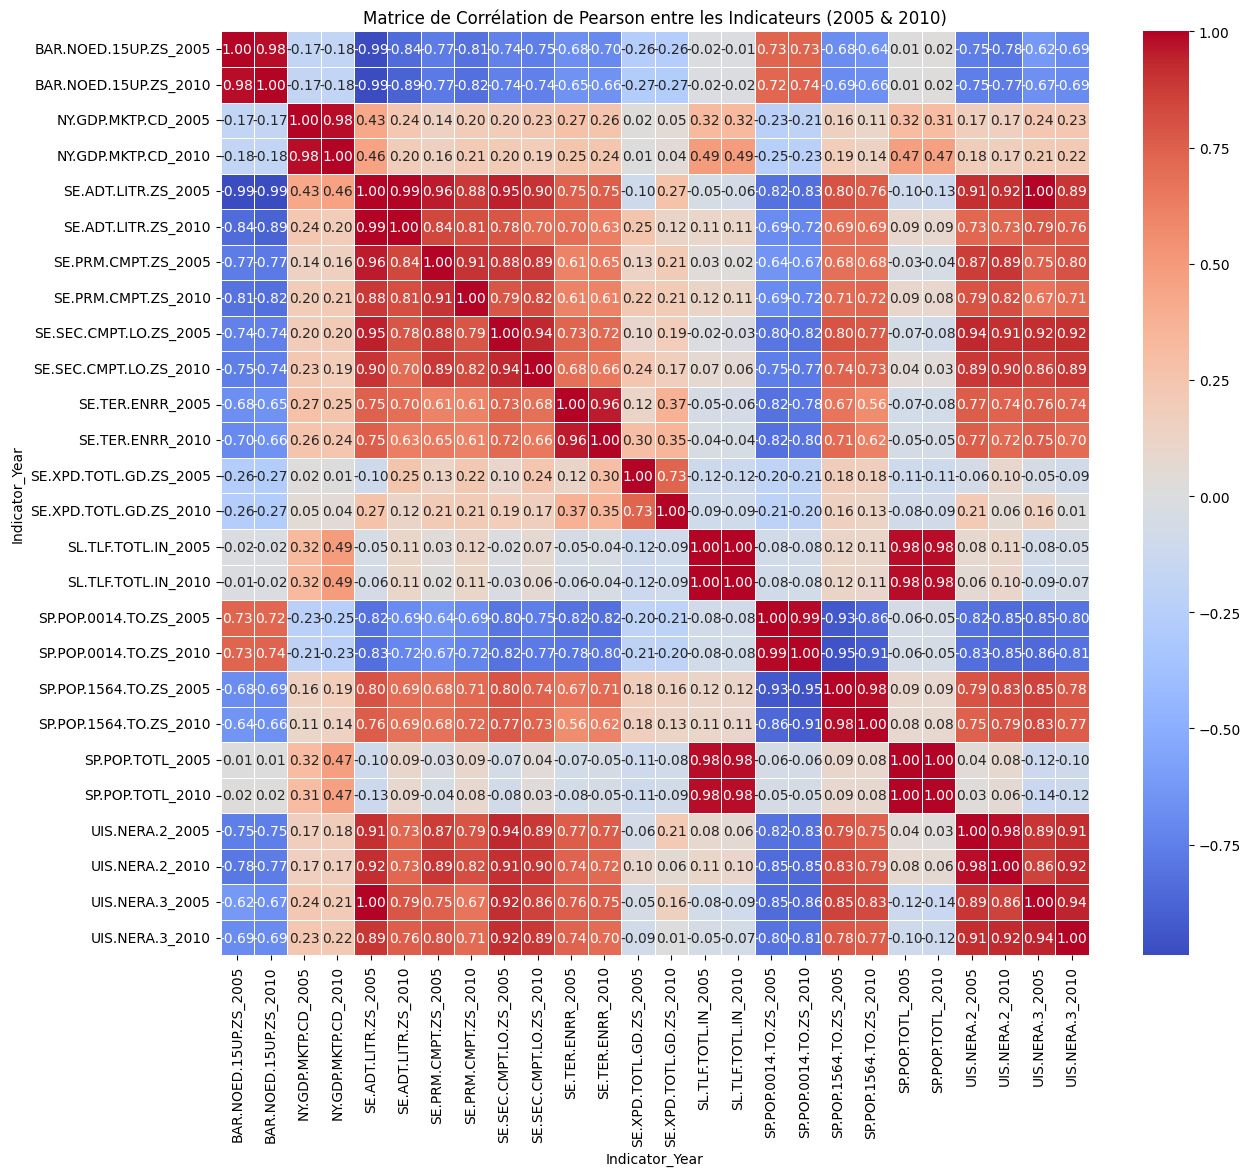


Tableau des 15 pays les mieux classés (résultat final) :


,Short Name,Table Name,Long Name,2-alpha code,Currency Unit,Special Notes,Region,Income Group,WB-2 code,National accounts base year,...,IMF data dissemination standard,Latest population census,Latest household survey,Source of most recent Income and expenditure data,Vital registration complete,Latest agricultural census,Latest industrial data,Latest trade data,Latest water withdrawal data,Unnamed: 31
Country Code,,,,,,,,,,,,,,,,,,,,,
JPN,Japan,Japan,Japan,JP,Japanese yen,Fiscal year end: March 31; reporting period fo...,East Asia & Pacific,High income: OECD,JP,2005,...,Special Data Dissemination Standard (SDDS),2010,NaN,"Income survey (IS), 1993",Yes,2010,2010.0,2012.0,2001,NaN
FRA,France,France,French Republic,FR,Euro,A simple multiplier is used to convert the nat...,Europe & Central Asia,High income: OECD,FR,Original chained constant price data are resca...,...,Special Data Dissemination Standard (SDDS),2006. Rolling census based on continuous sampl...,NaN,"Expenditure survey/budget survey (ES/BS), 1994/95",Yes,2010,2009.0,2012.0,2007,NaN
ITA,Italy,Italy,Italian Republic,IT,Euro,A simple multiplier is used to convert the nat...,Europe & Central Asia,High income: OECD,IT,2005,...,Special Data Dissemination Standard (SDDS),2012,NaN,"Expenditure survey/budget survey (ES/BS), 2000",Yes,2010,2009.0,2012.0,2000,NaN
CHN,China,China,People's Republic of China,CN,Chinese yuan,On 1 July 1997 China resumed its exercise of s...,East Asia & Pacific,Upper middle income,CN,2000,...,General Data Dissemination System (GDDS),2010,National Sample Survey on Population Change (N...,"Integrated household survey (IHS), 2008",NaN,2007,2007.0,2012.0,2005,NaN
UKR,Ukraine,Ukraine,Ukraine,UA,Ukrainian hryvnia,NaN,Europe & Central Asia,Lower middle income,UA,Original chained constant price data are resca...,...,Special Data Dissemination Standard (SDDS),2001,"Multiple Indicator Cluster Survey (MICS), 2012","Expenditure survey/budget survey (ES/BS), 2009",Yes,2012 /2013,NaN,2012.0,2005,NaN
ESP,Spain,Spain,Kingdom of Spain,ES,Euro,A simple multiplier is used to convert the nat...,Europe & Central Asia,High income: OECD,ES,2005,...,Special Data Dissemination Standard (SDDS),2011,NaN,"Integrated household survey (IHS), 2000",Yes,2010,2009.0,2012.0,2008,NaN
GRC,Greece,Greece,Hellenic Republic,GR,Euro,A simple multiplier is used to convert the nat...,Europe & Central Asia,High income: OECD,GR,Original chained constant price data are resca...,...,Special Data Dissemination Standard (SDDS),2011,NaN,"Integrated household survey (IHS), 2000",Yes,2009,2007.0,2012.0,2007,NaN
POL,Poland,Poland,Republic of Poland,PL,Polish zloty,NaN,Europe & Central Asia,High income: OECD,PL,Original chained constant price data are resca...,...,Special Data Dissemination Standard (SDDS),2011,NaN,"Expenditure survey/budget survey (ES/BS), 2010",Yes,2010,2009.0,2012.0,2009,NaN
KAZ,Kazakhstan,Kazakhstan,Republic of Kazakhstan,KZ,Kazakh tenge,NaN,Europe & Central Asia,Upper middle income,KZ,Original chained constant price data are resca...,...,Special Data Dissemination Standard (SDDS),2009,"Multiple Indicator Cluster Survey (MICS), 2010/11","Expenditure survey/budget survey (ES/BS), 2012",Yes,NaN,NaN,2012.0,2010,NaN


In [176]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd # S'assurer que pandas est importé

# Afficher la Heatmap de corrélation de Pearson (ou Spearman, selon celle jugée la plus pertinente)
print("\nHeatmap de la matrice de corrélation de Pearson (représentative des relations entre indicateurs) :")
if 'pearson_correlation_matrix' in dataframes:
    pearson_corr = dataframes['pearson_correlation_matrix']
    plt.figure(figsize=(14, 12)) # J'utilise la même taille que précédemment
    sns.heatmap(pearson_corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
    plt.title('Matrice de Corrélation de Pearson entre les Indicateurs (2005 & 2010)')
    plt.show()
elif 'spearman_correlation_matrix' in dataframes: # Afficher Spearman si Pearson n'est pas disponible
     spearman_corr = dataframes['spearman_correlation_matrix']
     plt.figure(figsize=(14, 12))
     sns.heatmap(spearman_corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
     plt.title('Matrice de Corrélation de Spearman entre les Indicateurs (2005 & 2010)')
     plt.show()
else:
    print("Aucune matrice de corrélation n'a été trouvée pour l'affichage.")


# Afficher le tableau des pays sélectionnés
print(f"\nTableau des {len(dataframes.get('final_country_list', []))} pays les mieux classés (résultat final) :")
if 'top_countries_details' in dataframes:
    display(dataframes['top_countries_details'])
elif 'final_country_list' in dataframes and 'EdStatsCountry_cleaned' in dataframes:
     # Si les détails ne sont pas stockés directement, je les reconstruis
     top_country_codes = dataframes['final_country_list']
     edstats_country_cleaned = dataframes['EdStatsCountry_cleaned'].set_index('Country Code')
     # Je m'assure que les codes existent dans le DataFrame des pays nettoyé avant de faire .loc
     existing_top_country_details = edstats_country_cleaned.loc[top_country_codes].copy()
     display(existing_top_country_details[['Short Name', 'Table Name', 'Long Name', '2-alpha code', 'Currency Unit', 'Region', 'Income Group']])
else:
    print("Les détails des pays sélectionnés n'ont pas été trouvés pour l'affichage.")

### Visualisations Représentatives de la Conclusion

Voici les visualisations clés qui soutiennent ma conclusion et ma préconisation.


Heatmap de la matrice de corrélation de Pearson (représentative des relations entre indicateurs) :


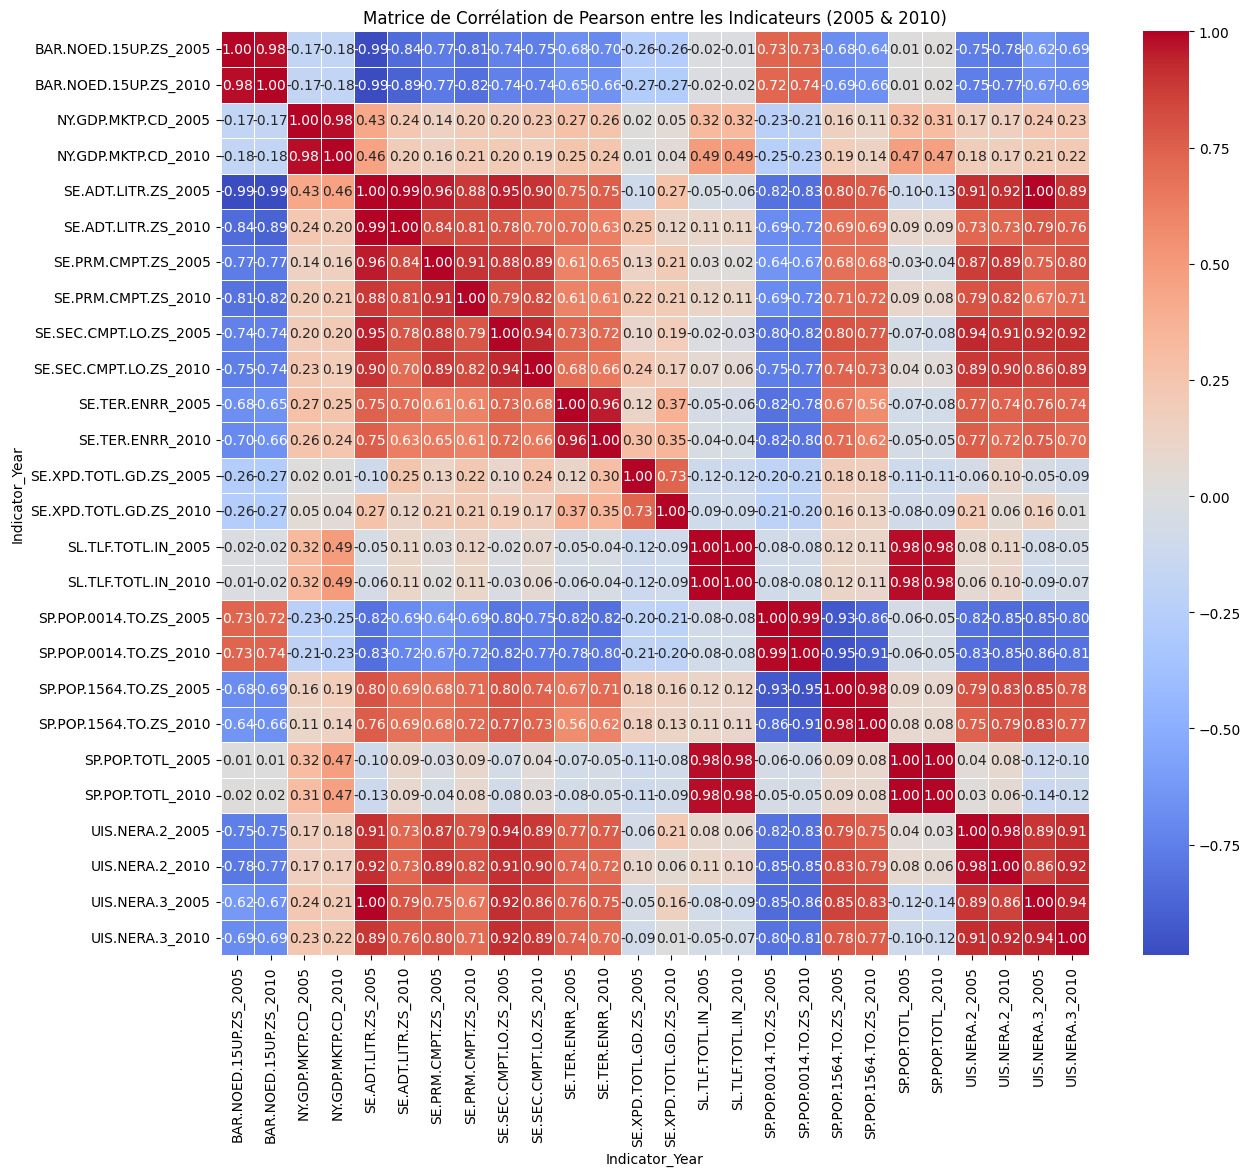


Tableau des 15 pays les mieux classés (résultat final) :


,Short Name,Table Name,Long Name,2-alpha code,Currency Unit,Special Notes,Region,Income Group,WB-2 code,National accounts base year,...,IMF data dissemination standard,Latest population census,Latest household survey,Source of most recent Income and expenditure data,Vital registration complete,Latest agricultural census,Latest industrial data,Latest trade data,Latest water withdrawal data,Unnamed: 31
Country Code,,,,,,,,,,,,,,,,,,,,,
JPN,Japan,Japan,Japan,JP,Japanese yen,Fiscal year end: March 31; reporting period fo...,East Asia & Pacific,High income: OECD,JP,2005,...,Special Data Dissemination Standard (SDDS),2010,NaN,"Income survey (IS), 1993",Yes,2010,2010.0,2012.0,2001,NaN
FRA,France,France,French Republic,FR,Euro,A simple multiplier is used to convert the nat...,Europe & Central Asia,High income: OECD,FR,Original chained constant price data are resca...,...,Special Data Dissemination Standard (SDDS),2006. Rolling census based on continuous sampl...,NaN,"Expenditure survey/budget survey (ES/BS), 1994/95",Yes,2010,2009.0,2012.0,2007,NaN
ITA,Italy,Italy,Italian Republic,IT,Euro,A simple multiplier is used to convert the nat...,Europe & Central Asia,High income: OECD,IT,2005,...,Special Data Dissemination Standard (SDDS),2012,NaN,"Expenditure survey/budget survey (ES/BS), 2000",Yes,2010,2009.0,2012.0,2000,NaN
CHN,China,China,People's Republic of China,CN,Chinese yuan,On 1 July 1997 China resumed its exercise of s...,East Asia & Pacific,Upper middle income,CN,2000,...,General Data Dissemination System (GDDS),2010,National Sample Survey on Population Change (N...,"Integrated household survey (IHS), 2008",NaN,2007,2007.0,2012.0,2005,NaN
UKR,Ukraine,Ukraine,Ukraine,UA,Ukrainian hryvnia,NaN,Europe & Central Asia,Lower middle income,UA,Original chained constant price data are resca...,...,Special Data Dissemination Standard (SDDS),2001,"Multiple Indicator Cluster Survey (MICS), 2012","Expenditure survey/budget survey (ES/BS), 2009",Yes,2012 /2013,NaN,2012.0,2005,NaN
ESP,Spain,Spain,Kingdom of Spain,ES,Euro,A simple multiplier is used to convert the nat...,Europe & Central Asia,High income: OECD,ES,2005,...,Special Data Dissemination Standard (SDDS),2011,NaN,"Integrated household survey (IHS), 2000",Yes,2010,2009.0,2012.0,2008,NaN
GRC,Greece,Greece,Hellenic Republic,GR,Euro,A simple multiplier is used to convert the nat...,Europe & Central Asia,High income: OECD,GR,Original chained constant price data are resca...,...,Special Data Dissemination Standard (SDDS),2011,NaN,"Integrated household survey (IHS), 2000",Yes,2009,2007.0,2012.0,2007,NaN
POL,Poland,Poland,Republic of Poland,PL,Polish zloty,NaN,Europe & Central Asia,High income: OECD,PL,Original chained constant price data are resca...,...,Special Data Dissemination Standard (SDDS),2011,NaN,"Expenditure survey/budget survey (ES/BS), 2010",Yes,2010,2009.0,2012.0,2009,NaN
KAZ,Kazakhstan,Kazakhstan,Republic of Kazakhstan,KZ,Kazakh tenge,NaN,Europe & Central Asia,Upper middle income,KZ,Original chained constant price data are resca...,...,Special Data Dissemination Standard (SDDS),2009,"Multiple Indicator Cluster Survey (MICS), 2010/11","Expenditure survey/budget survey (ES/BS), 2012",Yes,NaN,NaN,2012.0,2010,NaN


In [175]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd # S'assurer que pandas est importé

# Afficher la Heatmap de corrélation de Pearson (ou Spearman, selon celle jugée la plus pertinente)
print("\nHeatmap de la matrice de corrélation de Pearson (représentative des relations entre indicateurs) :")
if 'pearson_correlation_matrix' in dataframes:
    pearson_corr = dataframes['pearson_correlation_matrix']
    plt.figure(figsize=(14, 12)) # J'utilise la même taille que précédemment
    sns.heatmap(pearson_corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
    plt.title('Matrice de Corrélation de Pearson entre les Indicateurs (2005 & 2010)')
    plt.show()
elif 'spearman_correlation_matrix' in dataframes: # Afficher Spearman si Pearson n'est pas disponible
     spearman_corr = dataframes['spearman_correlation_matrix']
     plt.figure(figsize=(14, 12))
     sns.heatmap(spearman_corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
     plt.title('Matrice de Corrélation de Spearman entre les Indicateurs (2005 & 2010)')
     plt.show()
else:
    print("Aucune matrice de corrélation n'a été trouvée pour l'affichage.")


# Afficher le tableau des pays sélectionnés
print(f"\nTableau des {len(dataframes.get('final_country_list', []))} pays les mieux classés (résultat final) :")
if 'top_countries_details' in dataframes:
    display(dataframes['top_countries_details'])
elif 'final_country_list' in dataframes and 'EdStatsCountry_cleaned' in dataframes:
     # Si les détails ne sont pas stockés directement, je les reconstruis
     top_country_codes = dataframes['final_country_list']
     edstats_country_cleaned = dataframes['EdStatsCountry_cleaned'].set_index('Country Code')
     # Je m'assure que les codes existent dans le DataFrame des pays nettoyé avant de faire .loc
     existing_top_country_details = edstats_country_cleaned.loc[top_country_codes].copy()
     display(existing_top_country_details[['Short Name', 'Table Name', 'Long Name', '2-alpha code', 'Currency Unit', 'Region', 'Income Group']])
else:
    print("Les détails des pays sélectionnés n'ont pas été trouvés pour l'affichage.")